# Домашнее задание "Варианционные автоэнкодеры"

В этом домашнем задании вам предстоит реализовать несколько версий автоэнкодера для работы с изображениями.

Вы научитесь добавлять улыбку на фотографии людей, изменяя их исходное выражение лица с помощью обученной модели. А также, обучите ваш автоэнкодер генерировать изображения рукописных цифр.

# Часть 1. Vanilla Autoencoder (10 баллов)

## 1.1. Подготовка данных (1 балл)


Перед тем, как начинать работу с моделями нужно подготовить данные.

In [1]:
import numpy as np
from torch.autograd import Variable
from torchvision import datasets
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data_utils
import torch
import matplotlib.pyplot as plt

import os
import pandas as pd
import skimage.io
from skimage.transform import resize

import imageio
from PIL import Image
import kagglehub

%matplotlib inline

from sklearn.model_selection import train_test_split
import torchvision.transforms as transforms
from tqdm import tqdm
from sklearn.manifold import TSNE
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'


В этом задании вам предстоить работать с датасетом [LFW (Labeled Faces in the Wild)](https://datasets.activeloop.ai/docs/ml/datasets/lfw-dataset/#:~:text=What%20is%20LFW%20Dataset%3F,commercial%20algorithms%20prior%20to%20release).

In [2]:
# Скачиваем картинки
images_path = kagglehub.dataset_download("jessicali9530/lfw-dataset")
print("Path to dataset files:", images_path)

Path to dataset files: /home/user404/.cache/kagglehub/datasets/jessicali9530/lfw-dataset/versions/4


In [3]:
# Скачиваем атрибуты
attrs_path = kagglehub.dataset_download("averkij/lfw-attributes")
print("Path to dataset files:", attrs_path)

Path to dataset files: /home/user404/.cache/kagglehub/datasets/averkij/lfw-attributes/versions/1


In [4]:
DATASET_PATH = '/home/user404/.cache/kagglehub/datasets/jessicali9530/lfw-dataset/versions/4'

#"/kaggle/input/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled/"
ATTRIBUTES_PATH = '/home/user404/.cache/kagglehub/datasets/averkij/lfw-attributes/versions/1/lfw_attributes.txt'

#"/kaggle/input/lfw-attributes/lfw_attributes.txt"

In [5]:
def fetch_dataset(dx=80, dy=80, dimx=45, dimy=45):

    df_attrs = pd.read_csv(ATTRIBUTES_PATH, sep='\t', skiprows=1,)
    df_attrs = pd.DataFrame(df_attrs.iloc[:, :-1].values, columns = df_attrs.columns[1:])

    photo_ids = []
    for dirpath, dirnames, filenames in os.walk(DATASET_PATH):
        for fname in filenames:
            if fname.endswith(".jpg"):
                fpath = os.path.join(dirpath, fname)
                photo_id = fname[:-4].replace('_', ' ').split()
                person_id = ' '.join(photo_id[:-1])
                photo_number = int(photo_id[-1])
                photo_ids.append({'person': person_id,
                                  'imagenum': photo_number,
                                  'photo_path': fpath
                                  })

    photo_ids = pd.DataFrame(photo_ids)
    df = pd.merge(df_attrs,photo_ids,on=('person', 'imagenum'))

    assert len(df) == len(df_attrs), "Потеряны данные при объединении датафреймов!"

    images = df['photo_path'].apply(imageio.imread)\
                                .apply(lambda img:img[dy:-dy, dx:-dx])\
                                .apply(lambda img: np.array(Image.fromarray(img).resize([dimx, dimy])))

    images = np.stack(images.values).astype('uint8')

    attrs = df.drop(["photo_path","person","imagenum"],axis=1)

    return images, attrs

In [6]:
# Обратите внимание, что датасет представляет собой не только картинки, но и атрибуты
# Атрибуты понадобятся в конце этого задания

images, attrs = fetch_dataset()


Разбейте датасет изображений и атрибутов на train и val, выведите несколько картинок в output, чтобы посмотреть, как они выглядят, и приведите картинки к тензорам pytorch, чтобы можно было скормить их сети:

In [7]:
# <тут Ваш код>

train_photos, val_photos, train_attrs, val_attrs = train_test_split(
    images,
    attrs,
    train_size=0.9,
    shuffle=False
)

In [8]:
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    #transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),

])

train_photos_tensor = torch.stack([transform(photo) for photo in train_photos])
val_photos_tensor = torch.stack([transform(photo) for photo in val_photos])

train_loader = torch.utils.data.DataLoader(train_photos_tensor, batch_size=32, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_photos_tensor, batch_size=32, shuffle=False)

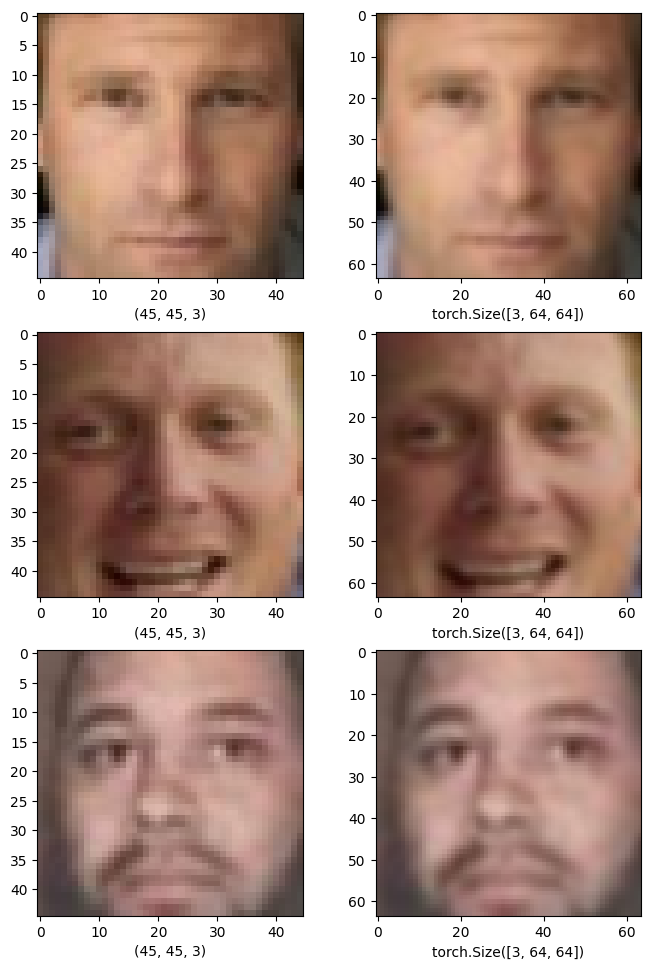

In [9]:
plt.figure(figsize=(8, 20))
for i in range(3):
  plt.subplot(5, 2, 2*i+1)
  plt.imshow(train_photos[i])
  plt.xlabel(train_photos[i].shape)
  plt.subplot(5, 2, 2*i+2)
  Image = np.clip(train_loader.dataset[i], 0, 1)
  plt.imshow(Image.permute(1, 2, 0))
  plt.xlabel(train_loader.dataset[i].shape)

plt.show()

## 1.2. Архитектура модели (2 балла)
В этом разделе вы напишите и обучите обычный автоэнкодер.



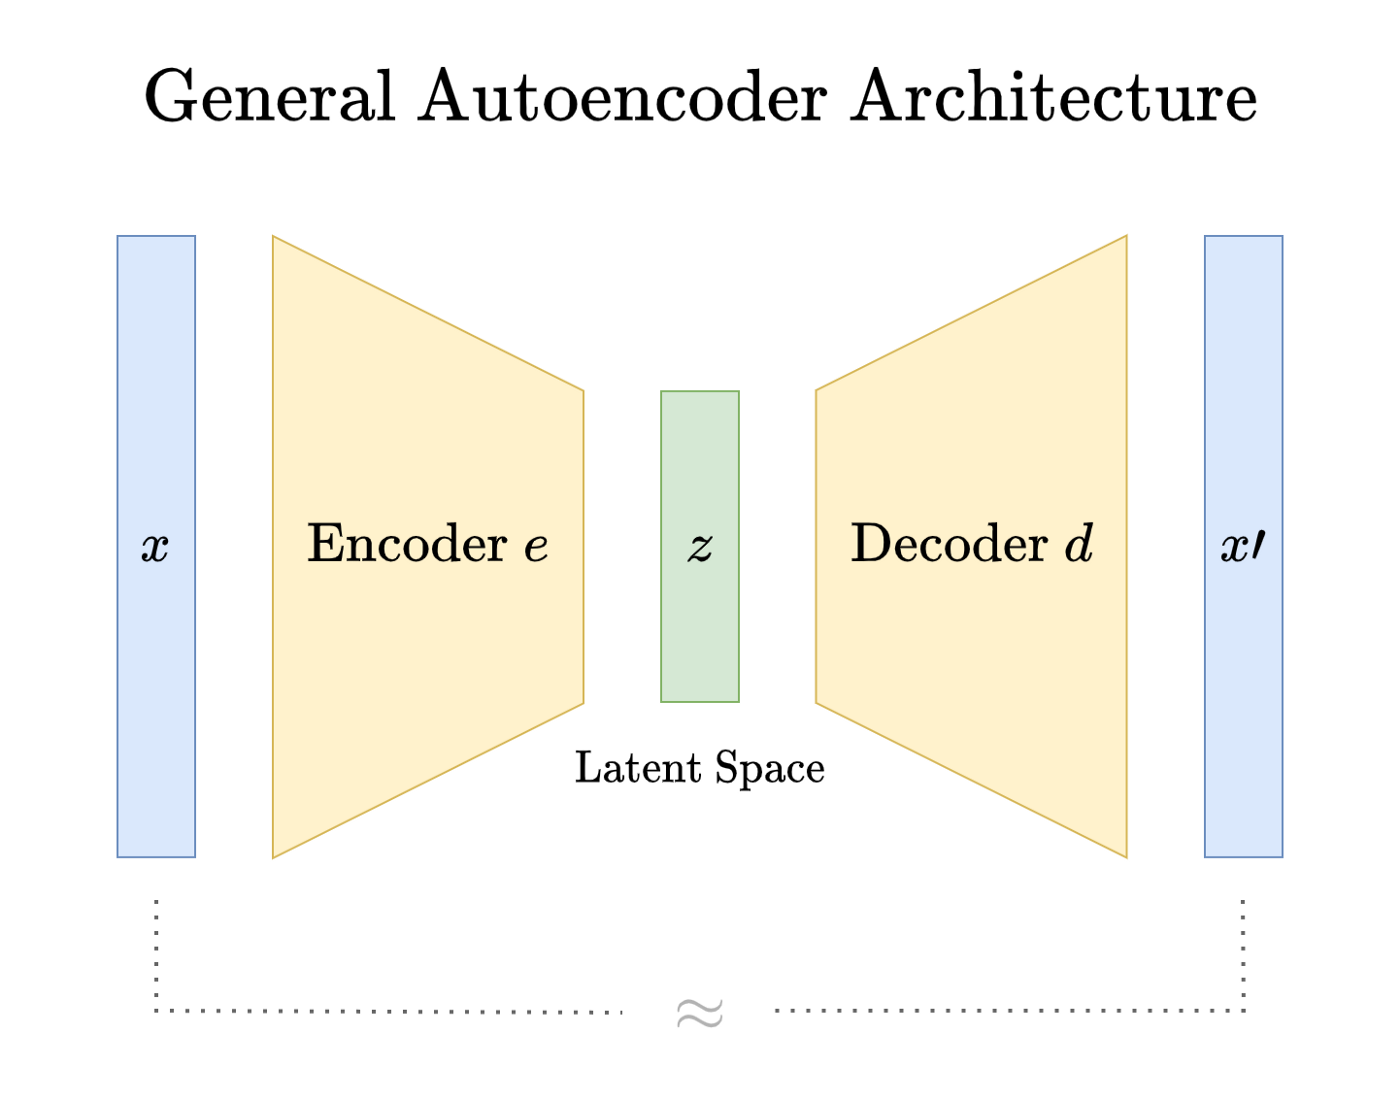

In [10]:
dim_code = 32 #<your code here> # выберите размер латентного вектора

In [ ]:
print("train_photos_tensor shape:", train_photos_tensor.shape)
print("First batch shape:", next(iter(train_loader)).shape)

Реализуем autoencoder. Архитектуру (conv, fully-connected, ReLu, etc) можете выбирать сами. Экспериментируйте!

In [11]:
class Autoencoder(nn.Module):
    def __init__(self, latent_dim, in_channels=3, dropout_p=0.1):
        super(Autoencoder, self).__init__()
        self.latent_dim = latent_dim
        self.in_channels = in_channels

        # encoder
        self.encoder_conv = nn.Sequential(
            # (B, 3, 64, 64)
            nn.Conv2d(in_channels, 32, 3, stride=2, padding=1),   # 32×32
            nn.LeakyReLU(),
            nn.BatchNorm2d(32),

            nn.Conv2d(32, 64, 3, stride=2, padding=1),            # 16×16
            nn.LeakyReLU(),
            nn.Dropout2d(dropout_p),
            nn.BatchNorm2d(64),

            nn.Conv2d(64, 128, 3, stride=2, padding=1),           # 8×8
            nn.LeakyReLU(),
            nn.BatchNorm2d(128),

            nn.Conv2d(128, 256, 3, stride=2, padding=1),          # 4×4
            nn.LeakyReLU(),
            nn.Dropout2d(dropout_p),
            nn.BatchNorm2d(256),
        )
        
        self.conv_out_shape = (256, 4, 4)  # каналы × H × W
        self.flat_size = 256 * 4 * 4  # = 4096

        self.encoder_fc = nn.Linear(self.flat_size, latent_dim)

        #decoder 
        self.decoder_fc = nn.Linear(latent_dim, self.flat_size)
        self.unflatten = nn.Unflatten(1, self.conv_out_shape)

        self.decoder = nn.Sequential(
            
            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1),  # 8×8
            nn.BatchNorm2d(128),
            nn.LeakyReLU(),

            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),   # 16×16
            nn.BatchNorm2d(64),
            nn.LeakyReLU(),
            nn.Dropout2d(dropout_p),

            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),    # 32×32
            nn.BatchNorm2d(32),
            nn.LeakyReLU(),

            nn.ConvTranspose2d(32, in_channels, 4, stride=2, padding=1),  # 64×64
            nn.Sigmoid()  # выход в [0, 1]
        )

    def encode(self, x):
        z_conv = self.encoder_conv(x)          
        z_flat = torch.flatten(z_conv, 1)     
        z = self.encoder_fc(z_flat)            # (B, latent_dim)
        return z

    def decode(self, z):
        z_dec = self.decoder_fc(z)             
        z_reshaped = self.unflatten(z_dec)     
        x_recon = self.decoder(z_reshaped)    
        return x_recon

    def forward(self, x):
        latent = self.encode(x)
        recon = self.decode(latent)
        return recon, latent

In [18]:
criterion = nn.MSELoss() # <loss>

autoencoder32 = Autoencoder(latent_dim=dim_code).to(device)

optimizer = torch.optim.AdamW(autoencoder32.parameters(),
                              lr=1e-3) # <Ваш любимый оптимизатор>

In [19]:
autoencoder32(train_loader.dataset[:1].to(device))

(tensor([[[[0.5475, 0.5073, 0.5827,  ..., 0.5353, 0.6015, 0.5434],
           [0.4998, 0.4296, 0.5219,  ..., 0.3218, 0.4086, 0.5525],
           [0.5031, 0.6438, 0.5242,  ..., 0.5850, 0.5226, 0.5671],
           ...,
           [0.4908, 0.5189, 0.5500,  ..., 0.4641, 0.5320, 0.5593],
           [0.5190, 0.5902, 0.5562,  ..., 0.5157, 0.5194, 0.5825],
           [0.5110, 0.5111, 0.5383,  ..., 0.5258, 0.4899, 0.5205]],
 
          [[0.5265, 0.4774, 0.4705,  ..., 0.4855, 0.4465, 0.5156],
           [0.4709, 0.4972, 0.5932,  ..., 0.6685, 0.5472, 0.4982],
           [0.5008, 0.4610, 0.5528,  ..., 0.6002, 0.4741, 0.4865],
           ...,
           [0.4560, 0.6353, 0.5578,  ..., 0.6640, 0.6482, 0.4686],
           [0.4374, 0.4965, 0.5909,  ..., 0.5263, 0.5357, 0.4800],
           [0.5181, 0.5158, 0.5880,  ..., 0.5508, 0.6435, 0.5160]],
 
          [[0.4497, 0.4703, 0.3998,  ..., 0.4960, 0.4605, 0.4573],
           [0.5216, 0.3960, 0.5544,  ..., 0.5116, 0.3812, 0.4155],
           [0.4155, 0.44

## 1.3 Обучение (2 балла)

Осталось написать код обучения автоэнкодера. При этом было бы неплохо в процессе иногда смотреть, как автоэнкодер реконструирует изображения на данном этапе обучения. Наример, после каждой эпохи (прогона train выборки через автоэнкодер) можно смотреть, какие реконструкции получились для каких-то изображений val выборки.

А, ну еще было бы неплохо выводить графики train и val лоссов в процессе тренировки =)

In [20]:
def train_loop(autoencoder,
               n_epochs = 50,
               train_losses = [],
               val_losses = [],
               patience = 5,
               min_delta = 1e-4,
               best_val_loss = float('inf'),
               epochs_no_improve = 0):
    
    plt.ion()
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    train_line, = ax.plot([], [], 'b-', label='Train')
    val_line, = ax.plot([], [], 'r--', label='Val')
    ax.legend(); plt.tight_layout(); ax.grid()
    
    for epoch in range(n_epochs):        
        autoencoder.train()
        total_train_loss = 0.0
        
        for batch in train_loader:
            batch = batch.to(device)
            
            optimizer.zero_grad()
            
            recon, _ = autoencoder(batch)
            
            loss = criterion(recon, batch)
            loss.backward()
            
            optimizer.step()
            
            total_train_loss += loss.item()   
            
        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)
            
        autoencoder.eval()
        
        total_val_loss = 0.0
        
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                recon, _ = autoencoder(batch)
                
                loss = criterion(recon, batch)
                total_val_loss += loss.item()
        
        avg_val_loss = total_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)
        
        if avg_val_loss < best_val_loss - min_delta:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            
            print(f'сохраняем улучшение...')
            torch.save(autoencoder.state_dict(), 'best_autoencoder.pth')
        else:
            epochs_no_improve += 1
            
        if (epoch % 3) == 0:
            print(f'Epoch {epoch+1}/{n_epochs} | Train: {avg_train_loss:.6f} | Val: {avg_val_loss:.6f}')

        
        xs = list(range(1, len(train_losses)+1))
        train_line.set_data(xs, train_losses)
        val_line.set_data(xs, val_losses)
        ax.relim(); ax.autoscale_view()
        fig.canvas.draw(); fig.canvas.flush_events()
        
        if epochs_no_improve >= patience:
            print(f'я это больше не могу... | {epoch+1}/{n_epochs}')
            break

    plt.ioff()
    plt.show()



сохраняем улучшение...
Epoch 1/50 | Train: 0.011472 | Val: 0.006913
сохраняем улучшение...
сохраняем улучшение...
Epoch 4/50 | Train: 0.005117 | Val: 0.004918
сохраняем улучшение...
Epoch 7/50 | Train: 0.004793 | Val: 0.004528
сохраняем улучшение...
Epoch 10/50 | Train: 0.004584 | Val: 0.004326
сохраняем улучшение...
Epoch 13/50 | Train: 0.004475 | Val: 0.004184
Epoch 16/50 | Train: 0.004380 | Val: 0.004154
я это больше не могу... | 17/50


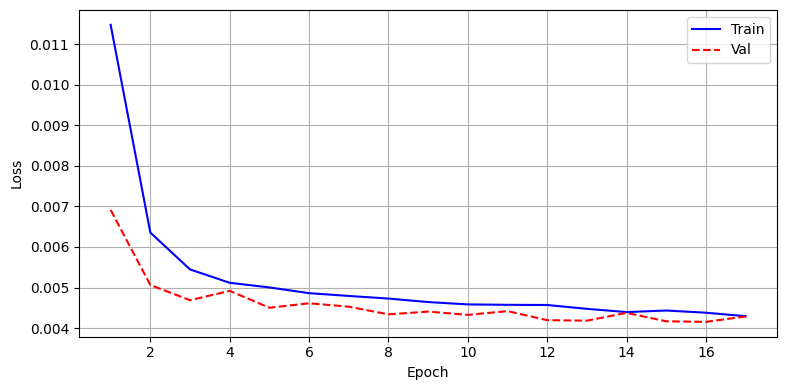

In [21]:
train_loop(autoencoder=autoencoder32)

In [22]:
autoencoder32.load_state_dict(torch.load('best_autoencoder.pth', map_location=device))

autoencoder32.eval()

Autoencoder(
  (encoder_conv): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.01)
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (4): LeakyReLU(negative_slope=0.01)
    (5): Dropout2d(p=0.1, inplace=False)
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (8): LeakyReLU(negative_slope=0.01)
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (11): LeakyReLU(negative_slope=0.01)
    (12): Dropout2d(p=0.1, inplace=False)
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (encoder_fc): Linear(in_features=4096, out_fe

Давайте посмотрим, как наш тренированный автоэнкодер кодирует и восстанавливает картинки:

In [25]:
def eval_loop(autoencoder):
    autoencoder.eval()
    
    with torch.no_grad():
        sample_batch = next(iter(val_loader))[:5].to(device)
        recon = autoencoder(sample_batch)[0]

    plt.figure(figsize=(8, 16))
    for i, (gt, res) in enumerate(zip(sample_batch.cpu(), recon.cpu())):
        plt.subplot(5, 2, 2*i+1)
        plt.imshow(gt.permute(1, 2, 0))
        plt.subplot(5, 2, 2*i+2)
        plt.imshow(res.permute(1, 2, 0))
    plt.show()


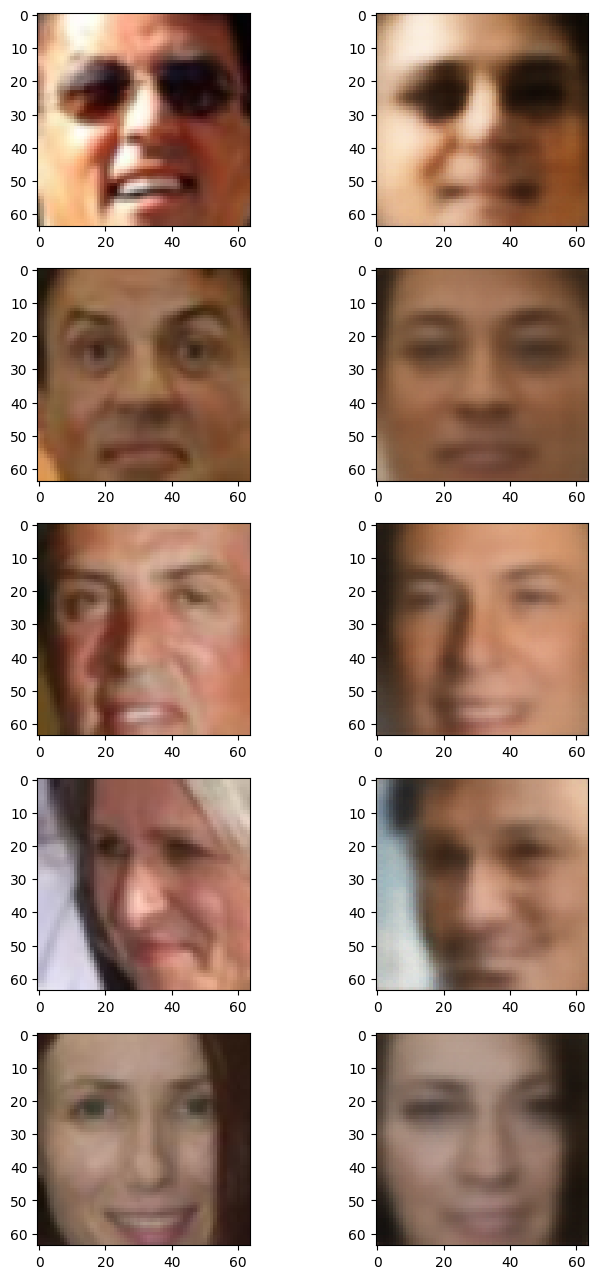

In [26]:
eval_loop(autoencoder32)

Что вы можете сказать про результат?

результат зависит от архитектуры.

в целом, простая сверточная сеть удовлетворительно справляется. но ей понадобилось много эпох (27) для обучения и генерации размытые получаются. 

результат, который выше - это с добавленными батчнорм и скипконнекшн. дропаут немного помог избежать быстрого переобучения.

также, результат может зависить от размера латентного вектора. 

попробую его увеличить

сохраняем улучшение...
Epoch 1/50 | Train: 0.010918 | Val: 0.005256
сохраняем улучшение...
сохраняем улучшение...
сохраняем улучшение...
Epoch 4/50 | Train: 0.003397 | Val: 0.002590
сохраняем улучшение...
сохраняем улучшение...
Epoch 7/50 | Train: 0.002656 | Val: 0.002038
сохраняем улучшение...
сохраняем улучшение...
Epoch 10/50 | Train: 0.002293 | Val: 0.001713
сохраняем улучшение...
Epoch 13/50 | Train: 0.002089 | Val: 0.001580
сохраняем улучшение...
Epoch 16/50 | Train: 0.001926 | Val: 0.001564
сохраняем улучшение...
Epoch 19/50 | Train: 0.001805 | Val: 0.001343
Epoch 22/50 | Train: 0.001718 | Val: 0.001281
сохраняем улучшение...
Epoch 25/50 | Train: 0.001628 | Val: 0.001183
Epoch 28/50 | Train: 0.001532 | Val: 0.001198
я это больше не могу... | 28/50


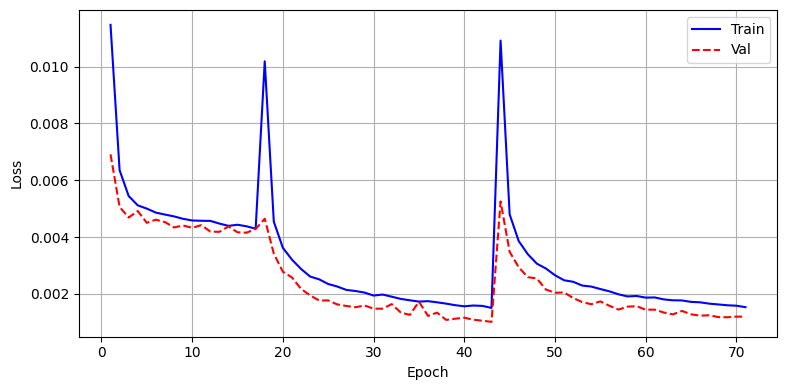

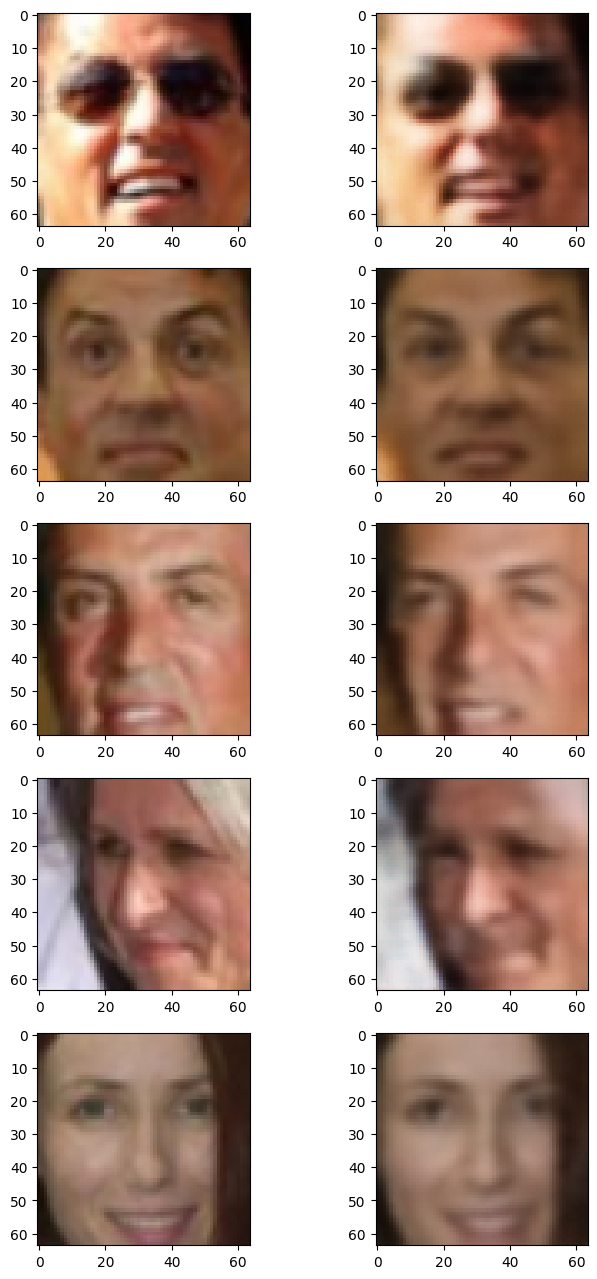

In [60]:
autoencoder128 = Autoencoder(
    latent_dim=256
).to(device)

optimizer = torch.optim.AdamW(
    autoencoder128.parameters(),
    lr=5e-4,
    weight_decay=1e-4
) # <Ваш любимый оптимизатор>

train_loop(autoencoder=autoencoder128)
autoencoder128.load_state_dict(
    torch.load('best_autoencoder.pth',
               map_location=device)
)

eval_loop(autoencoder128)

уже лучше, но все равно есть артефакты

## 1.4. Sampling (2 балла)

Давайте теперь будем не просто брать картинку, прогонять ее через автоэнкодер и получать реконструкцию, а попробуем создать что-то НОВОЕ!

Давайте возьмем и подсунем декодеру какие-нибудь сгенерированные нами векторы (например, из нормального распределения) и посмотрим на результат реконструкции декодера:

__Подсказка:__ Если вместо лиц у вас выводится непонятно что, попробуйте посмотреть, как выглядят латентные векторы картинок из датасета. Так как в обучении нейронных сетей есть определенная доля рандома, векторы латентного слоя могут быть распределены НЕ как `np.random.randn(25, <latent_space_dim>)`. А чтобы у нас получались лица при запихивании вектора декодеру, вектор должен быть распределен так же, как латентные векторы реальных фоток. Так что в таком случае придется рандом немного подогнать.

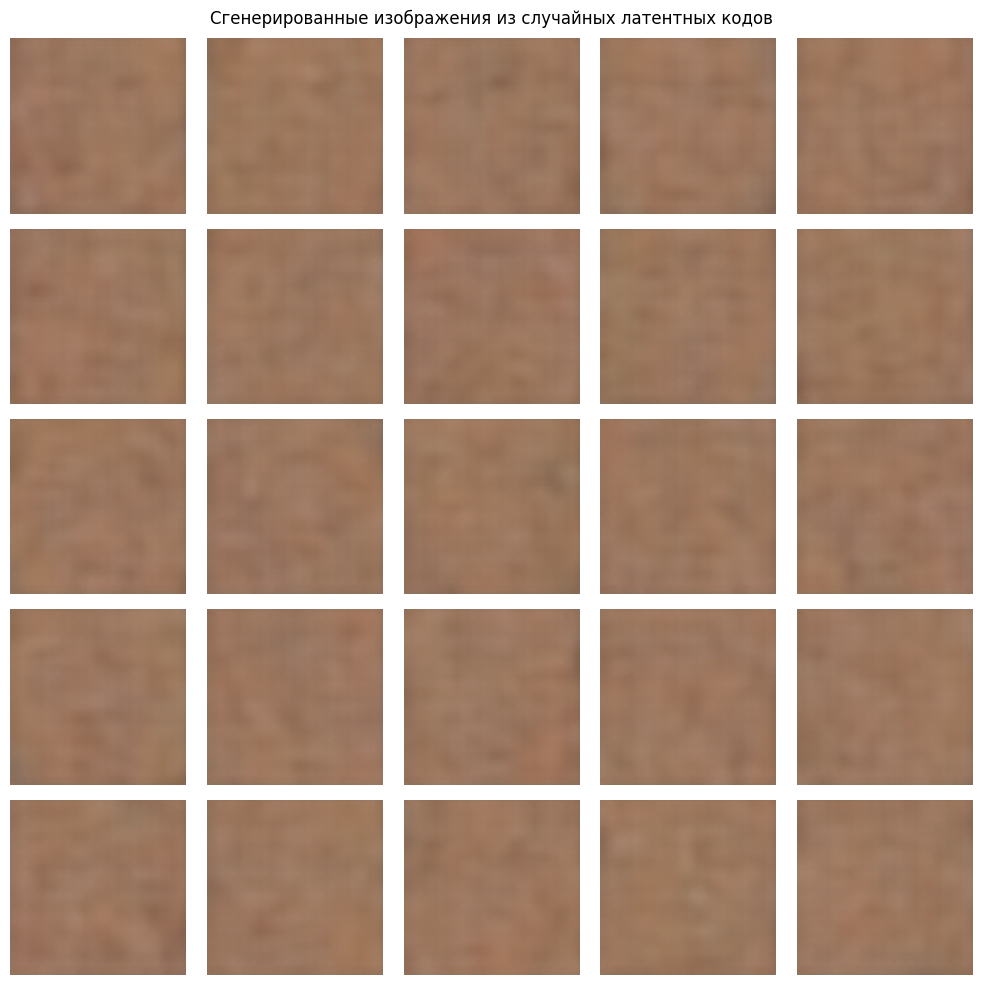

In [62]:
# сгенерируем 25 рандомных векторов размера latent_space
z = torch.randn(25, 256).to(device) # <latent_space_dim>
output = autoencoder128.decode(z) # <скормите z декодеру>
# <выведите тут полученные картинки>

fig, axes = plt.subplots(5, 5, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    img = output[i].cpu().permute(1, 2, 0).detach().numpy()
    ax.imshow(np.clip(img, 0, 1))
    ax.axis('off')
plt.suptitle("Сгенерированные изображения из случайных латентных кодов")
plt.tight_layout()
plt.show()


In [63]:
autoencoder128.eval()
latents = []

with torch.no_grad():
    for batch in val_loader:  #или train_loader
        batch = batch.to(device)
        _, z = autoencoder128(batch)   # z.shape = [B, dim_code, 4, 4]
        latents.append(z.cpu().numpy())

latents = np.concatenate(latents, axis=0)   #[N, dim_code, 4, 4]
print("Собрано", latents.shape[0], "латентных тензоров")

Собрано 1315 латентных тензоров


In [64]:
latents.shape

(1315, 256)

In [65]:
# Статистики по каждому измерению
z_mean = latents.mean(axis=0)   # [D]
z_std = latents.std(axis=0)     # [D]

print("Mean (min/max):", z_mean.min().round(3), "/", z_mean.max().round(3))
print("Std  (min/max):", z_std.min().round(3), "/", z_std.max().round(3))

Mean (min/max): -20.435 / 18.606
Std  (min/max): 4.329 / 33.029


In [66]:
n_samples = 25

# шум НОРМАЛЬНЫЙ, но с нужной статистикой
z_gen = torch.from_numpy(np.random.randn(n_samples, latents.shape[1]) * z_std + z_mean).float().to(device)

In [67]:
z_gen.shape

torch.Size([25, 256])

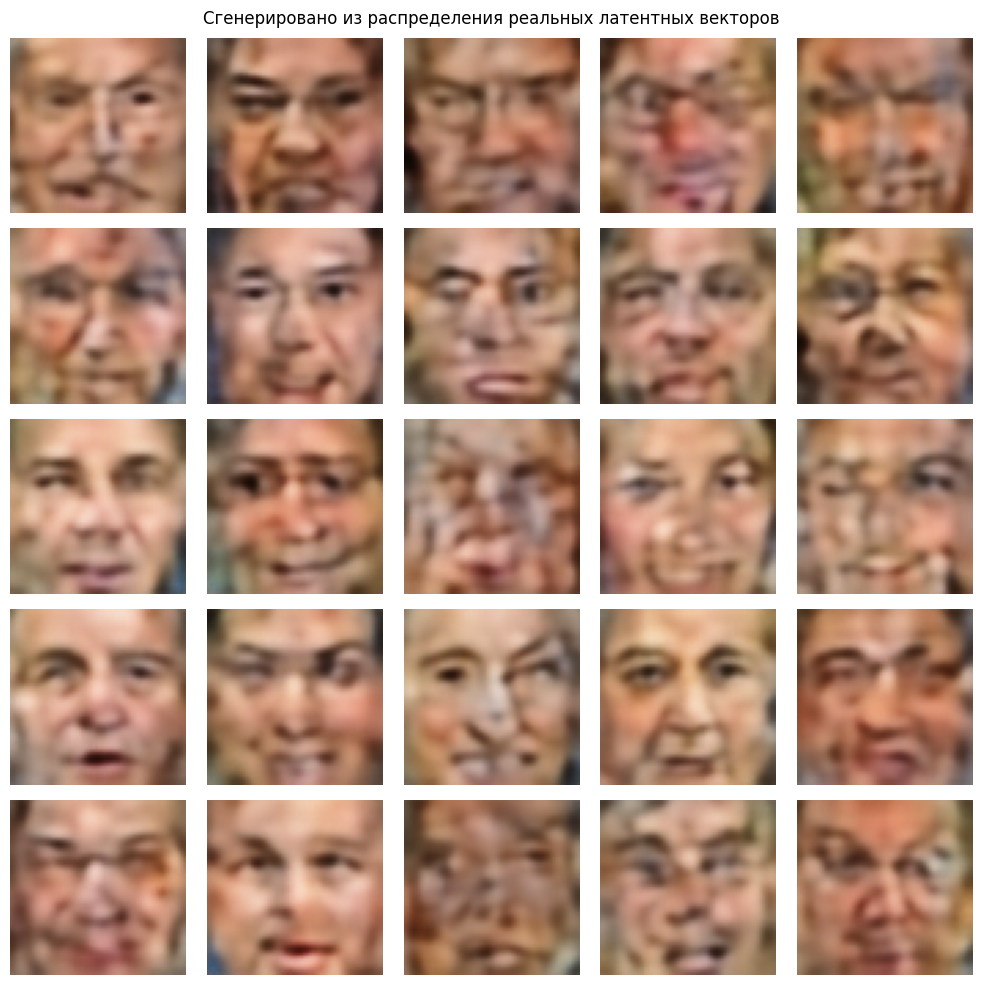

In [68]:
with torch.no_grad():
    gen_imgs = autoencoder128.decode(z_gen)  

fig, axes = plt.subplots(5, 5, figsize=(10, 10))

for i, ax in enumerate(axes.flat):
    img = gen_imgs[i].cpu().permute(1, 2, 0).numpy()
    ax.imshow(np.clip(img, 0, 1))
    ax.axis('off')
plt.suptitle("Сгенерировано из распределения реальных латентных векторов")
plt.tight_layout()
plt.show()

## 1.5 Time to make fun! (3 балла)

Давайте научимся пририсовывать людям улыбки =)

<img src="https://i.imgur.com/tOE9rDK.png" alt="linear" width="700" height="400">

План такой:

1. Нужно выделить "вектор улыбки": для этого нужно из выборки изображений найти несколько (~15) людей с улыбками и столько же без.

Найти людей с улыбками вам поможет файл с атрибутами, скачанный вместе с картинками. В нем указаны имена изображений и присутствубщие атрибуты (улыбки, очки и прочее интересное).

2. Вычислить латентный вектор для всех улыбающихся людей (прогнать их через encoder) и то же для всех грустненьких.

3. Вычислить, собственно, вектор улыбки -- посчитать разность между средним латентным вектором улыбающихся людей и средним латентным вектором грустных людей.

4. А теперь приделаем улыбку грустному человеку: добавим полученный в пункте 3 вектор к латентному вектору грустного человека и прогоним полученный вектор через decoder. Получим того же человека, но уже не грустненького!

In [69]:
train_attrs.head()

,Male,Asian,White,Black,Baby,Child,Youth,Middle Aged,Senior,Black Hair,...,Pale Skin,5 o' Clock Shadow,Strong Nose-Mouth Lines,Wearing Lipstick,Flushed Face,High Cheekbones,Brown Eyes,Wearing Earrings,Wearing Necktie,Wearing Necklace
0,1.568346,-1.889043,1.737203,-0.929729,-1.471799,-0.19558,-0.835609,-0.351468,-1.012533,-0.719593,...,0.361738,1.166118,-1.164916,-1.13999,-2.371746,-1.299932,-0.414682,-1.144902,0.694007,-0.826609
1,0.169851,-0.982408,0.422709,-1.282184,-1.36006,-0.867002,-0.452293,-0.197521,-0.956073,-0.802107,...,-0.832036,-0.39768,0.87416,-0.945431,-0.268649,-0.006244,-0.030406,-0.480128,0.66676,-0.496559
2,0.997749,-1.364195,-0.157377,-0.756447,-1.891825,-0.871526,-0.862893,0.031445,-1.341523,-0.090037,...,1.549743,1.884745,-0.999765,-1.359858,-1.912108,-1.095634,0.915126,-0.572332,0.144262,-0.841231
3,1.122719,-1.997799,1.916144,-2.514214,-2.580071,-1.404239,0.057551,0.000196,-1.273512,-1.431462,...,0.567822,-0.176089,1.108125,-1.600944,-3.264613,0.813418,0.308631,-0.848693,0.475941,-0.447025
4,1.078214,-2.008098,1.676211,-2.278056,-2.651845,-1.348408,0.649089,0.017656,-1.889111,-1.857213,...,-1.461474,-0.955283,0.119113,-1.128176,-3.161048,0.08268,-0.439614,-0.359859,-0.760774,-0.410152


In [70]:
train_attrs.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11828 entries, 0 to 11827
Data columns (total 73 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Male                        11828 non-null  object
 1   Asian                       11828 non-null  object
 2   White                       11828 non-null  object
 3   Black                       11828 non-null  object
 4   Baby                        11828 non-null  object
 5   Child                       11828 non-null  object
 6   Youth                       11828 non-null  object
 7   Middle Aged                 11828 non-null  object
 8   Senior                      11828 non-null  object
 9   Black Hair                  11828 non-null  object
 10  Blond Hair                  11828 non-null  object
 11  Brown Hair                  11828 non-null  object
 12  Bald                        11828 non-null  object
 13  No Eyewear                  11828 non-null  object


In [71]:
train_attrs['Smiling']

0        -0.86499
1        0.798544
2        0.172817
3        0.563327
4        0.507786
           ...   
11823    1.201503
11824    0.347114
11825   -1.135493
11826    1.565299
11827     1.14576
Name: Smiling, Length: 11828, dtype: object

In [72]:
index = {
    'smile': attrs.sort_values(
        by='Smiling', ascending=False
    )[:150].index,
    'not_smile': attrs.sort_values(
        by=['Frowning', 'Arched Eyebrows','Mouth Closed'], ascending=False
    )[:150].index
}

In [73]:
index

{'smile': Index([ 8643,  1816, 13034,  5624,  1045,  4681,  6139, 11797,  1359,  2031,
        ...
         1822,  8381,  7758,  8134,  8026,  6146, 10254,  8387,   650,  1767],
       dtype='int64', length=150),
 'not_smile': Index([10491,  6321,  2529, 12992,  3559, 11571,  8504, 10506,  5641,  7506,
        ...
         5495, 11818, 11951,  5396, 10501,  8037, 12303,  5858,  1139, 10851],
       dtype='int64', length=150)}

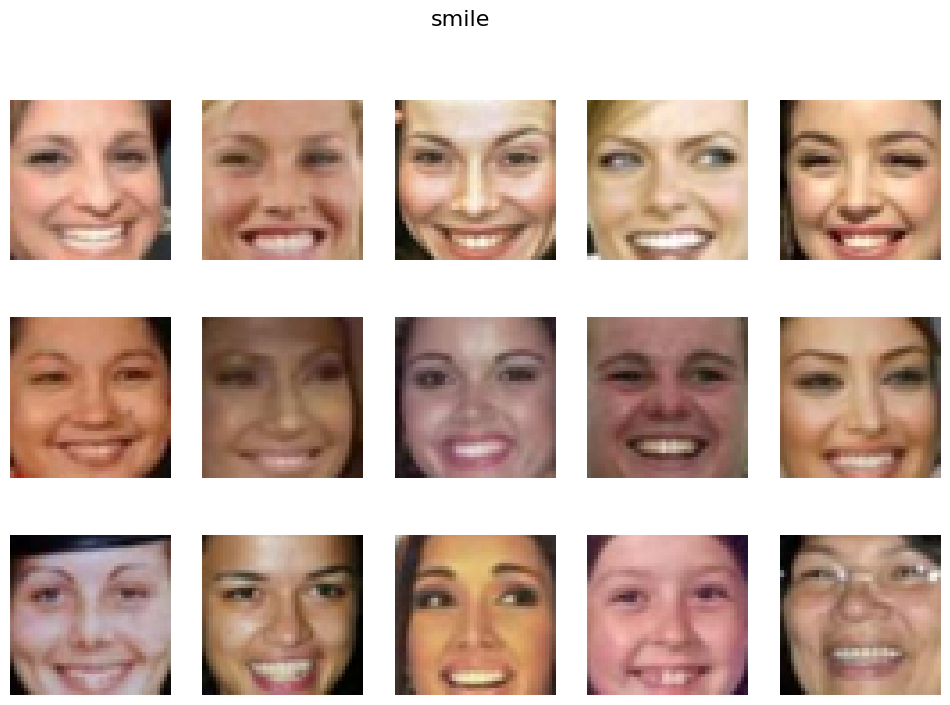

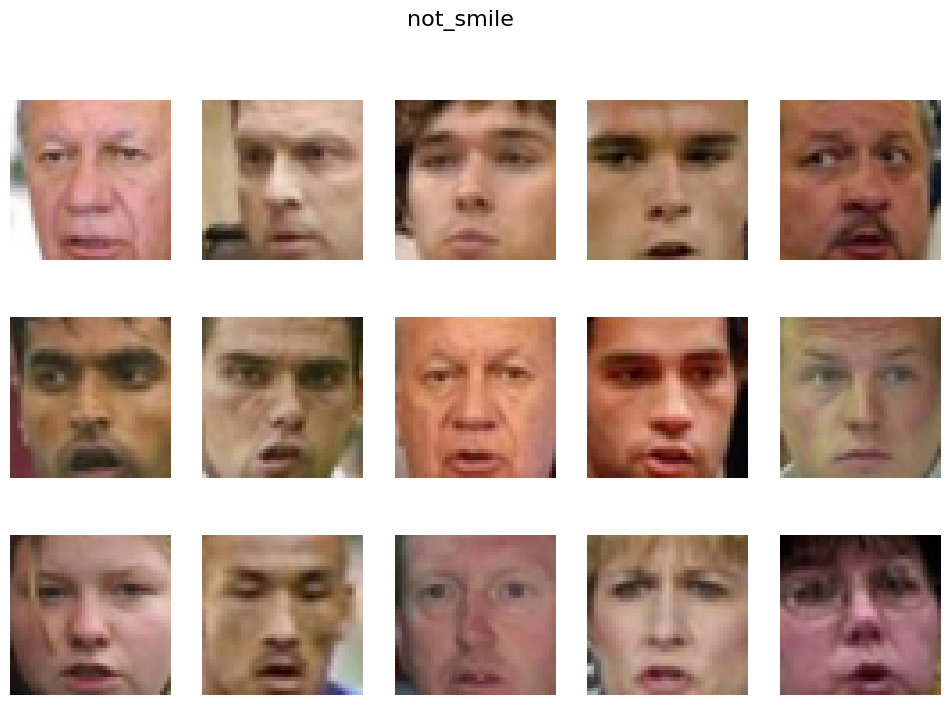

In [74]:
for k, v in index.items():
    fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(12, 8))
    for i, ax in enumerate(axes.flat):
        ax.imshow(images[v][i])
        ax.set_axis_off()
    plt.suptitle(k, fontsize=16)
    plt.show()

In [75]:
smiling_imgs = torch.stack([transform(p) for p in images[index['smile']]])
not_smiling_imgs = torch.stack([transform(p) for p in images[index['not_smile']]])

smiling_imgs = smiling_imgs.to(device)
not_smiling_imgs = not_smiling_imgs.to(device)

In [76]:
not_smiling_imgs.shape == not_smiling_imgs.shape

True

In [77]:
autoencoder128.eval()
with torch.no_grad():
    z_smile = autoencoder128.encode(smiling_imgs)      # (15, 128)
    z_not = autoencoder128.encode(not_smiling_imgs)    # (15, 128)

    #средние векторы
    mu_smile = z_smile.mean(dim=0)   # (128,)
    mu_not = z_not.mean(dim=0)       # (128,)

    # вктор улыбки
    smile_vec = mu_smile - mu_not    # (128,)
    print("Smile vector norm:", smile_vec.norm().item())

Smile vector norm: 62.120540618896484


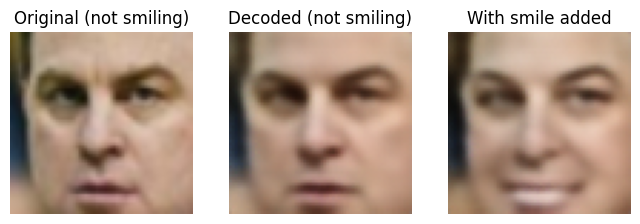

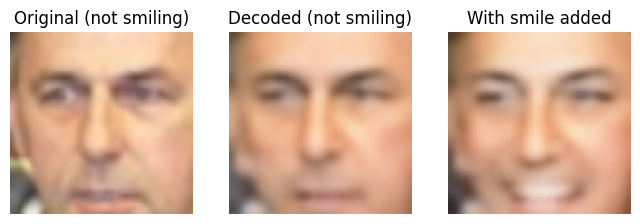

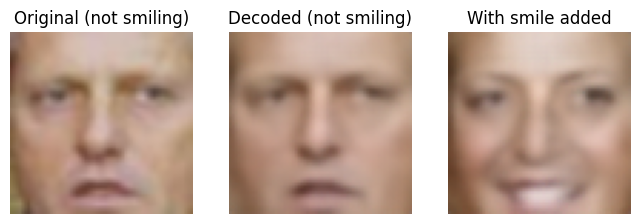

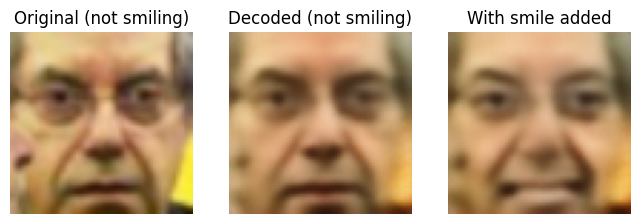

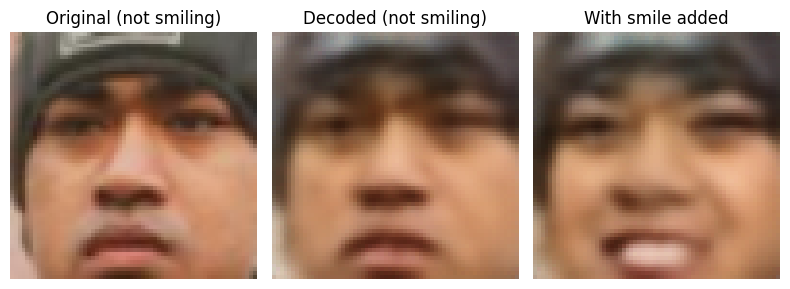

In [87]:
# грусть
nums = np.random.randint(1, 120, 5)
z = not_smiling_imgs[nums]
z_target = autoencoder128.encode(z)  # (1, 128)

# вектор улыбки (можно с коэффициентом)
z_smiled = z_target + smile_vec.unsqueeze(0)

# декодируем
with torch.no_grad():
    recon_orig = autoencoder128.decode(z_target)
    recon_smiled = autoencoder128.decode(z_smiled)

for i in range(5):    
    fig, axes = plt.subplots(1, 3, figsize=(8, 3))
    axes[0].imshow(z[i].cpu().permute(1,2,0))
    axes[0].set_title("Original (not smiling)")
    axes[0].axis('off')
    
    
    axes[1].imshow(recon_orig[i].cpu().permute(1,2,0))
    axes[1].set_title("Decoded (not smiling)")
    axes[1].axis('off')
    
    axes[2].imshow(recon_smiled[i].cpu().permute(1,2,0))
    axes[2].set_title("With smile added")
    axes[2].axis('off')

plt.tight_layout()
plt.show()


Вуаля! Вы восхитительны!

Теперь вы можете пририсовывать людям не только улыбки, но и много чего другого -- закрывать/открывать глаза, пририсовывать очки... В общем, все, на что хватит фантазии и на что есть атрибуты в `attrs`:)

# Часть 2: Variational Autoencoder (10 баллов)

Займемся обучением вариационных автоэнкодеров — проапгрейженной версии AE. Обучать будем на датасете MNIST, содержащем написанные от руки цифры от 0 до 9

In [88]:
batch_size = 32
# MNIST Dataset
train_dataset = datasets.MNIST(root='./mnist_data/', train=True, transform=transforms.ToTensor(), download=True)
test_dataset = datasets.MNIST(root='./mnist_data/', train=False, transform=transforms.ToTensor(), download=False)

# Data Loader (Input Pipeline)
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

## 2.1 Архитектура модели и обучение (2 балла)

Реализуем VAE. Архитектуру (conv, fully-connected, ReLu, etc) можете выбирать сами. Рекомендуем пользоваться более сложными моделями, чем та, что была на семинаре:) Экспериментируйте!

class VAE(nn.Module):
    def __init__(self):
        <определите архитектуры encoder и decoder
        помните, у encoder должны быть два "хвоста",
        т.е. encoder должен кодировать картинку в 2 переменные -- mu и logsigma>

    def encode(self, x):
        <реализуйте forward проход энкодера
        в качестве ваозвращаемых переменных -- mu и logsigma>

        return mu, logsigma

    def gaussian_sampler(self, mu, logsigma):
        if self.training:
            <засемплируйте латентный вектор из нормального распределения с параметрами mu и sigma>
        else:
            # на инференсе возвращаем не случайный вектор из нормального распределения, а центральный -- mu.
            # на инференсе выход автоэнкодера должен быть детерминирован.
            return mu

    def decode(self, z):
        <реализуйте forward проход декодера
        в качестве возвращаемой переменной -- reconstruction>

        return reconstruction

    def forward(self, x):
        <используя encode и decode, реализуйте forward проход автоэнкодера
        в качестве ваозвращаемых переменных -- mu, logsigma и reconstruction>
        return mu, logsigma, reconstruction

In [89]:
class SELayer(nn.Module):
    """channel attention)"""
    def __init__(self, channel, reduction=16):
        super(SELayer, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)  
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel // reduction, channel, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)           # squeeze
        y = self.fc(y).view(b, c, 1, 1)           # excitation
        return x * y.expand_as(x)                 # scale channels


class VAE(nn.Module):
    def __init__(self, latent_dim=64):
        super(VAE, self).__init__()
        
        self.latent_dim = latent_dim

        #encoder
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1),     # 28 → 14
            nn.LeakyReLU(0.2, inplace=True),
            nn.BatchNorm2d(32),

            nn.Conv2d(32, 64, 4, 2, 1),    # 14 → 7
            nn.LeakyReLU(0.2, inplace=True),
            nn.BatchNorm2d(64),

            nn.Conv2d(64, 128, 4, 2, 1),   # 7 → 3
            nn.LeakyReLU(0.2, inplace=True),
            nn.BatchNorm2d(128),
        )
        self.se_encoder = SELayer(128, reduction=8)  
        self.pool = nn.AdaptiveAvgPool2d((2, 2))     
        self.fc_in = 128 * 2 * 2
        self.fc_mu = nn.Linear(self.fc_in, latent_dim)
        self.fc_logsigma = nn.Linear(self.fc_in, latent_dim)

        # decoder
        self.fc_decode = nn.Linear(latent_dim, 128 * 7 * 7)
        self.unflatten = nn.Unflatten(1, (128, 7, 7))

        self.decoder_up1 = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),  # 7 → 14
            nn.LeakyReLU(0.2, inplace=True),
            nn.BatchNorm2d(64),
        )
        self.se_decoder = SELayer(64, reduction=8)  #SE после первого upsampling

        self.decoder_up2 = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),   # 14 → 28
            nn.LeakyReLU(0.2, inplace=True),
            nn.BatchNorm2d(32),
        )

        self.final_conv = nn.Sequential(
            nn.Conv2d(32, 1, kernel_size=3, stride=1, padding=1),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder_conv(x)            
        h = self.se_encoder(h)              
        h = self.pool(h)                    
        h = h.view(h.size(0), -1)           
        mu = self.fc_mu(h)
        logsigma = self.fc_logsigma(h)
        return mu, logsigma

    def gaussian_sampler(self, mu, logsigma):
        if self.training:
            std = torch.exp(0.5 * logsigma)
            eps = torch.randn_like(std)
            return mu + eps * std
        else:
            return mu

    def decode(self, z):
        h = self.fc_decode(z)               #[B, 128*7*7]
        h = self.unflatten(h)               # [B, 128, 7, 7]
        h = self.decoder_up1(h)             # [B, 64, 14, 14]
        h = self.se_decoder(h)              #attention
        h = self.decoder_up2(h)             # [B, 32, 28, 28]
        return self.final_conv(h)           # [B, 1, 28, 28]

    def forward(self, x):
        mu, logsigma = self.encode(x)
        z = self.gaussian_sampler(mu, logsigma)
        recon = self.decode(z)
        return recon, mu, logsigma

Определим лосс и его компоненты для VAE:

Надеюсь, вы уже прочитали материал в towardsdatascience (или еще где-то) про VAE и знаете, что лосс у VAE состоит из двух частей: KL и log-likelihood.

Общий лосс будет выглядеть так:

$$\mathcal{L} = -D_{KL}(q_{\phi}(z|x)||p(z)) + \log p_{\theta}(x|z)$$

Формула для KL-дивергенции:

$$D_{KL} = -\frac{1}{2}\sum_{i=1}^{dimZ}(1+log(\sigma_i^2)-\mu_i^2-\sigma_i^2)$$

В качестве log-likelihood возьмем привычную нам кросс-энтропию.

In [90]:
def KL_divergence(mu, logsigma):
    """
    часть функции потерь, которая отвечает за "близость" латентных представлений разных людей
    """
    #loss = <напишите код для KL-дивергенции, пользуясь формулой выше>
    #return
    pass

def log_likelihood(x, reconstruction):
    """
    часть функции потерь, которая отвечает за качество реконструкции (как mse в обычном autoencoder)
    """
    #loss = <binary cross-entropy>
    #return loss(reconstruction, x)
    pass

def loss_vae(x, mu, logsigma, reconstruction):
    #return <соедините тут две компоненты лосса. Mind the sign!>
    pass

In [91]:
def KL_divergence(mu, logsigma):
    # logsigma = log(σ²) ⇒ σ² = exp(logsigma)
    kl = -0.5 * torch.sum(1 + logsigma - mu.pow(2) - logsigma.exp(), dim=1)
    return kl.mean()  


def log_likelihood(x, reconstruction):
    bce = F.binary_cross_entropy(reconstruction, x, reduction='none')
    return bce.sum(dim=[1, 2, 3]).mean() 


def loss_vae(x, mu, logsigma, reconstruction):
    """
    Общий лосс
    """
    recon_loss = log_likelihood(x, reconstruction)
    kl_loss = KL_divergence(mu, logsigma)
    return recon_loss + kl_loss

И обучим модель:

In [92]:
def train_vae(
    model, 
    train_loader, 
    test_loader, 
    num_epochs=50, 
    lr=1e-3,
    device='cpu', 
    log_interval=10, 
    save_path='vae_best.pth',
    patience=10, 
    delta=0.0, 
    use_scheduler=True
):
    
    model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr)
    
    if use_scheduler:
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, 
            mode='min', 
            factor=0.5, 
            patience=5, 
            verbose=False
        )
    
    train_losses = []
    test_losses = []
    best_test_loss = float('inf')
    epochs_no_improve = 0
    early_stop = False

    for epoch in range(1, num_epochs + 1):
        # трейн
        model.train()
        train_loss = 0
        for data, _ in train_loader:
            data = data.to(device)
            optimizer.zero_grad()
            recon_batch, mu, logsigma = model(data)
            loss = loss_vae(data, mu, logsigma, recon_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # валидасьон
        model.eval()
        test_loss = 0
        with torch.no_grad():
            for data, _ in test_loader:
                data = data.to(device)
                recon_batch, mu, logsigma = model(data)
                loss = loss_vae(data, mu, logsigma, recon_batch)
                test_loss += loss.item()
                
        avg_test_loss = test_loss / len(test_loader)
        test_losses.append(avg_test_loss)

        #scheduler
        if use_scheduler:
            scheduler.step(avg_test_loss)  
            
        if use_scheduler and epoch % log_interval == 0:
            new_lr = optimizer.param_groups[0]['lr']
            prev_lr = getattr(train_vae, '_prev_lr', new_lr)
            if abs(new_lr - prev_lr) > 1e-8:
                print(f'LR корректировка {prev_lr:.1e} to {new_lr:.1e}')
                train_vae._prev_lr = new_lr  

        if epoch % log_interval == 0 or epoch == 1:
            log_msg = f'Epoch {epoch:03d} | Train: {avg_train_loss:.4f} | Test: {avg_test_loss:.4f}'

            if use_scheduler:
                current_lr = scheduler.optimizer.param_groups[0]['lr']
                log_msg += f' | LR: {current_lr:.1e}'
            
            print(log_msg)
            
        if avg_test_loss < best_test_loss - delta:
            best_test_loss = avg_test_loss
            epochs_no_improve = 0
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict() if use_scheduler else None,
                'test_loss': best_test_loss,
            }, save_path)
            if epoch % log_interval == 0:
                print(f'сохраняем улучшение... | (test loss: {best_test_loss:.4f})')
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f'я это больше не могу... {epoch=} | {best_test_loss=:.4f}')
                break

    return train_losses, test_losses

In [93]:
def plot_losses(train_losses, test_losses):
    plt.figure(figsize=(10, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss', color='tab:blue')
    plt.plot(test_losses, label='Test Loss', color='tab:orange')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('VAE Training Curve')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(train_losses, label='Total', alpha=0.7)
    plt.yscale('log')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (log scale)')
    plt.title('Log Scale')
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

In [94]:
def visualize_reconstructions(model, test_loader, device='cpu', n=8):
    model.eval()
    data, _ = next(iter(test_loader))
    data = data[:n].to(device)
    
    with torch.no_grad():
        recon, _, _ = model(data)
    
    fig, axes = plt.subplots(2, n, figsize=(n*1.5, 3))
    for i in range(n):
        # orig
        axes[0, i].imshow(data[i].cpu().squeeze(), cmap='gray')
        axes[0, i].axis('off')
        if i == 0: axes[0, i].set_title('orig')
        
        # reconst
        axes[1, i].imshow(recon[i].cpu().squeeze(), cmap='gray')
        axes[1, i].axis('off')
        if i == 0: axes[1, i].set_title('reconst')
    
    plt.suptitle('VAE reconst')
    plt.tight_layout()
    plt.show()

Epoch 001 | Train: 137.3543 | Test: 101.6063 | LR: 1.0e-03
Epoch 005 | Train: 104.3989 | Test: 91.8758 | LR: 1.0e-03
сохраняем улучшение... | (test loss: 91.8758)
Epoch 010 | Train: 101.4356 | Test: 89.9746 | LR: 1.0e-03
сохраняем улучшение... | (test loss: 89.9746)
Epoch 015 | Train: 99.9778 | Test: 88.9411 | LR: 1.0e-03
сохраняем улучшение... | (test loss: 88.9411)
Epoch 020 | Train: 99.0173 | Test: 88.8423 | LR: 1.0e-03
сохраняем улучшение... | (test loss: 88.8423)
Epoch 025 | Train: 98.3065 | Test: 87.6359 | LR: 1.0e-03
сохраняем улучшение... | (test loss: 87.6359)
Epoch 030 | Train: 97.7908 | Test: 88.0297 | LR: 1.0e-03
Epoch 035 | Train: 97.3559 | Test: 87.5609 | LR: 1.0e-03
Epoch 040 | Train: 96.9873 | Test: 87.4566 | LR: 1.0e-03
Epoch 045 | Train: 96.7109 | Test: 87.3523 | LR: 1.0e-03
Epoch 050 | Train: 96.4489 | Test: 87.1938 | LR: 5.0e-04


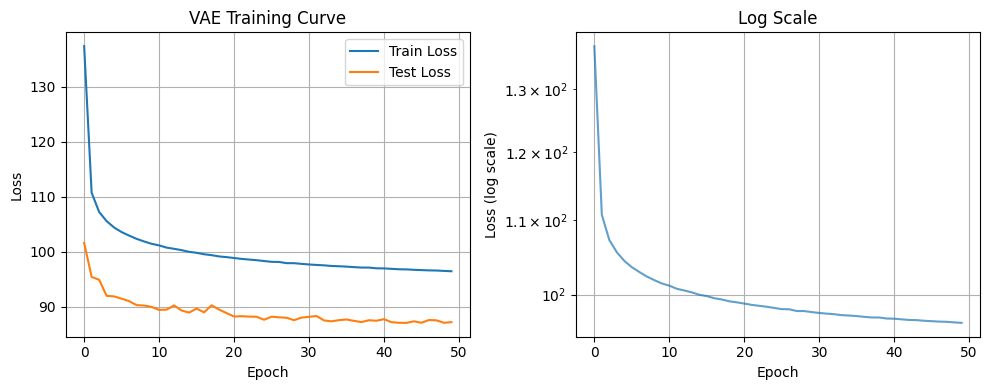

In [96]:
model = VAE(latent_dim=128).to(device)

train_losses, test_losses = train_vae(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    num_epochs=50,
    lr=1e-3,
    device=device,
    log_interval=5,
    save_path='vae_mnist_best.pth'
)

plot_losses(train_losses, test_losses)

Давайте посмотрим, как наш тренированный VAE кодирует и восстанавливает картинки:

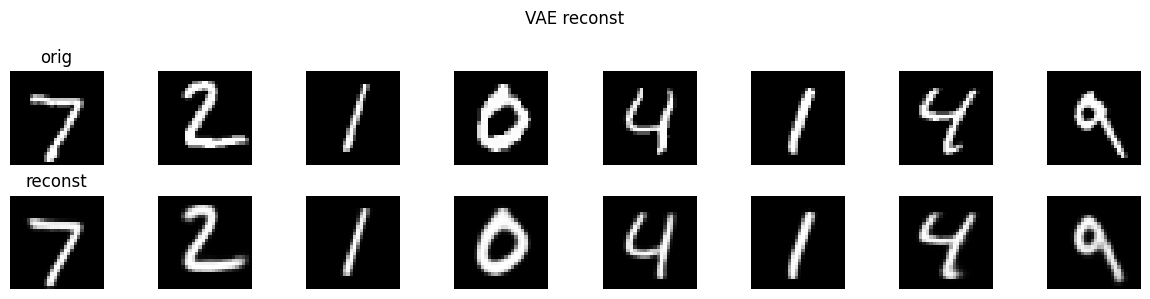

In [101]:
model.load_state_dict(
    torch.load(
        'vae_mnist_best.pth', 
        map_location=device
    )['model_state_dict']
)

visualize_reconstructions(model, test_loader, device=device)

Давайте попробуем проделать для VAE то же, что и с обычным автоэнкодером -- подсунуть decoder'у из VAE случайные векторы из нормального распределения и посмотреть, какие картинки получаются:

In [102]:
model.eval()
z = np.random.randn(10, 128)
output = model.decode(torch.FloatTensor(z).to(device))
output.shape

torch.Size([10, 1, 28, 28])

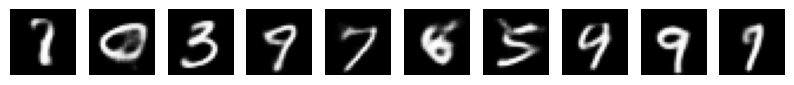

In [111]:
z = np.random.randn(10, 128)
output = model.decode(torch.FloatTensor(z).to(device)).cpu().detach().numpy()

plt.figure(figsize=(10, 2))
for i in range(output.shape[0]):
    plt.subplot(1, 10, i+1)
    plt.imshow(output[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
plt.show()

## 2.2. Latent Representation (2 балла)

Давайте посмотрим, как латентные векторы картинок лиц выглядят в пространстве.
Ваша задача -- изобразить латентные векторы картинок точками в двумерном просторанстве.

Это позволит оценить, насколько плотно распределены латентные векторы изображений цифр в пространстве.

Плюс давайте сделаем такую вещь: покрасим точки, которые соответствуют картинкам каждой цифры, в свой отдельный цвет

Подсказка: красить -- это просто =) У plt.scatter есть параметр c (color), см. в документации.


Итак, план:
1. Получить латентные представления картинок тестового датасета
2. С помощтю `TSNE` (есть в `sklearn`) сжать эти представления до размерности 2 (чтобы можно было их визуализировать точками в пространстве)
3. Визуализировать полученные двумерные представления с помощью `matplotlib.scatter`, покрасить разными цветами точки, соответствующие картинкам разных цифр.

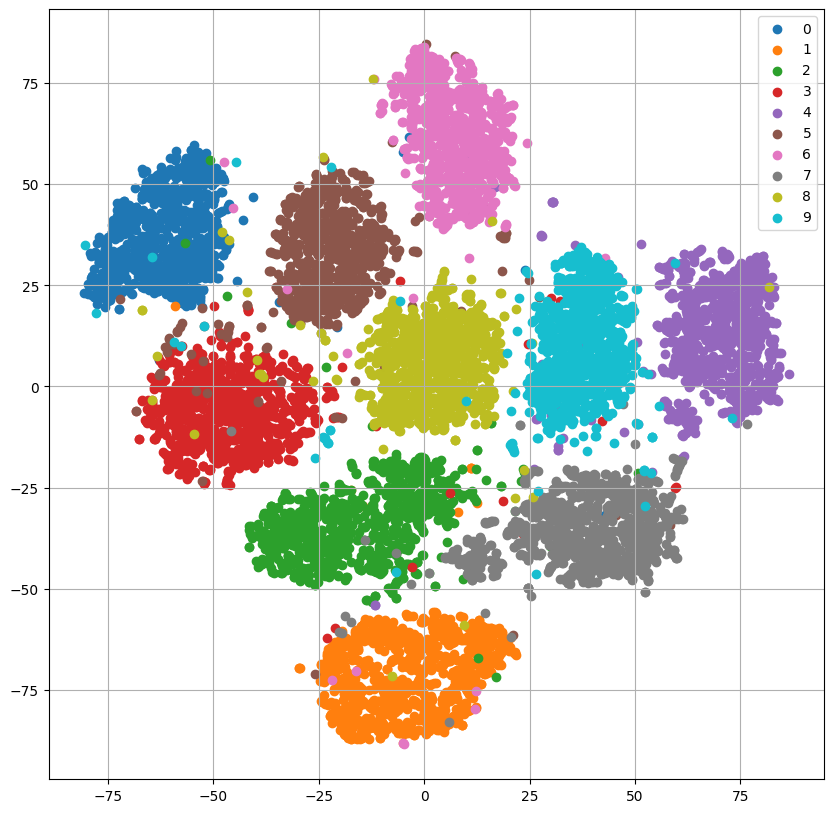

In [112]:
latent_vectors = []
labels = []
with torch.no_grad():
    for batch_idx, (data, target) in enumerate(test_loader):
        data = data.to(device)
        mu, logvar = model.encode(data)
        z = model.gaussian_sampler(mu, logvar)
        latent_vectors.append(z.cpu().numpy())
        labels.append(target.cpu().numpy())
latent_vectors = np.concatenate(latent_vectors, axis=0)
labels = np.concatenate(labels, axis=0)

#TSNE для сжатия латентных представлений до двух измерений
tsne = TSNE(n_components=2)
latent_vectors_tsne = tsne.fit_transform(latent_vectors)

# визуализация точек на двумерной плоскости, разными цветами для разных цифр
plt.figure(figsize=(10, 10))
for i in range(10):
    plt.scatter(latent_vectors_tsne[labels == i, 0], latent_vectors_tsne[labels == i, 1], label=str(i))
plt.legend()
plt.grid()
plt.show()


#<ваш код получения латентных представлений, применения TSNE и визуализации>

Что вы думаете о виде латентного представления?

есть четкое разделение по классам.

между классами заметны пересечения:

-- 1 (оранжевый) и 7 (серый) — они часто похожи по форме;

-- 5 (коричневый) и 6 (розовый) — частично смешиваются;

-- 8 (жёлтый) и 9 (бирюзовый) — тоже немного перекрываются.

скорее всего из-за похожести цифр в датасете

кластеры 0, 8, 9 — плотные и компактные.
кластеры 5, 6, 7, 2 — более растянуты.

может указывать на то, что модель менее уверена в этих классах.



__Congrats v2.0!__

## 2.3. Conditional VAE (6 баллов)


Мы уже научились обучать обычный AE на датасете картинок и получать новые картинки, используя генерацию шума и декодер.
Давайте теперь допустим, что мы обучили AE на датасете MNIST и теперь хотим генерировать новые картинки с числами с помощью декодера (как выше мы генерили рандомные лица).
И вот нам понадобилось сгенерировать цифру 8, и мы подставляем разные варианты шума, но восьмерка никак не генерится:(

Хотелось бы добавить к нашему AE функцию "выдай мне рандомное число из вот этого вот класса", где классов десять (цифры от 0 до 9 образуют десять классов).  Conditional AE — так называется вид автоэнкодера, который предоставляет такую возможность. Ну, название "conditional" уже говорит само за себя.

И в этой части задания мы научимся такие обучать.

### Архитектура

На картинке ниже представлена архитектура простого Conditional VAE.

По сути, единственное отличие от обычного -- это то, что мы вместе с картинкой в первом слое энкодера и декодера передаем еще информацию о классе картинки.

То есть, в первый (входной) слой энкодера подается конкатенация картинки и информации о классе (например, вектора из девяти нулей и одной единицы). В первый слой декодера подается конкатенация латентного вектора и информации о классе.


![alt text](https://sun9-63.userapi.com/impg/Mh1akf7mfpNoprrSWsPOouazSmTPMazYYF49Tw/djoHNw_9KVA.jpg?size=1175x642&quality=96&sign=e88baec5f9bb91c8443fba31dcf0a4df&type=album)

![alt text](https://sun9-73.userapi.com/impg/UDuloLNKhzTBYAKewgxke5-YPsAKyGOqA-qCRg/MnyCavJidxM.jpg?size=1229x651&quality=96&sign=f2d21bfacc1c5755b76868dc4cfef39c&type=album)



На всякий случай: это VAE, то есть, latent у него все еще состоит из mu и sigma

Таким образом, при генерации новой рандомной картинки мы должны будем передать декодеру сконкатенированные латентный вектор и класс картинки.

P.S. Также можно передавать класс картинки не только в первый слой, но и в каждый слой сети. То есть на каждом слое конкатенировать выход из предыдущего слоя и информацию о классе.


  class CVAE(nn.Module):

    def __init__(self):
        # <определите архитектуры encoder и decoder
        # помните, у encoder должны быть два "хвоста",
        # т.е. encoder должен кодировать картинку в 2 переменные -- mu и logsigma>

    def encode(self, x, class_num):
        # <реализуйте forward проход энкодера
        # в качестве возвращаемых переменных -- mu, logsigma и класс картинки>

        return mu, logsigma, class_num

    def gaussian_sampler(self, mu, logsigma):
        if self.training:
            # засемплируйте латентный вектор из нормального распределения с параметрами mu и sigma
        else:
            # на инференсе возвращаем не случайный вектор из нормального распределения, а центральный -- mu.
            # на инференсе выход автоэнкодера должен быть детерминирован.
            return mu

    def decode(self, z, class_num):
        # реализуйте forward проход декодера
        # в качестве возвращаемой переменной -- reconstruction

        return reconstruction

    def forward(self, x):
        # используя encode и decode, реализуйте forward проход автоэнкодера
        # в качестве ваозвращаемых переменных -- mu, logsigma и reconstruction
        return mu, logsigma, reconstruction

In [ ]:
class SELayer(nn.Module):
    def __init__(self, channel, reduction=8):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel // reduction, channel, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y

механизм Squeeze-and-Excitation (SE), предложенного в статье "Squeeze-and-Excitation Networks" 
[https://arxiv.org/abs/1709.01507?spm=a2ty_o01.29997173.0.0.7fdb5171QKvuL1&file=1709.01507]

что-то типа аттеншн

In [113]:
class CVAE(nn.Module):
    def __init__(self, latent_dim=64, num_classes=10):
        super(CVAE, self).__init__()
        self.latent_dim = latent_dim
        self.num_classes = num_classes

        # encoder
        # [B, 1, 28, 28] + [B, num_classes] 
        self.label_emb_enc = nn.Embedding(num_classes, 28 * 28)  
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(2, 32, 4, 2, 1),     # 2 канала: image + label_map
            nn.LeakyReLU(0.2, inplace=True),
            nn.BatchNorm2d(32),
            nn.Conv2d(32, 64, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.BatchNorm2d(64),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.BatchNorm2d(128),
        )
        self.se_encoder = SELayer(128, reduction=8)
        self.pool = nn.AdaptiveAvgPool2d((2, 2))
        self.fc_in = 128 * 2 * 2
        self.fc_mu = nn.Linear(self.fc_in, latent_dim)
        self.fc_logsigma = nn.Linear(self.fc_in, latent_dim)

        # decoder
        self.label_emb_dec = nn.Embedding(num_classes, latent_dim)  # эмбеддинг класса в латентное пространство
        self.fc_decode = nn.Linear(latent_dim + latent_dim, 128 * 7 * 7)  #z + label_emb
        self.unflatten = nn.Unflatten(1, (128, 7, 7))

        self.decoder_up1 = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1),  # 7 → 14
            nn.LeakyReLU(0.2, inplace=True),
            nn.BatchNorm2d(64),
        )
        self.se_decoder = SELayer(64, reduction=8)

        self.decoder_up2 = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 4, 2, 1),   # 14 → 28
            nn.LeakyReLU(0.2, inplace=True),
            nn.BatchNorm2d(32),
        )
        self.final_conv = nn.Sequential(
            nn.Conv2d(32, 1, 3, 1, 1),
            nn.Sigmoid()
        )

    def encode(self, x, class_labels):
        """
        x: [B, 1, 28, 28]
        class_labels: [B] - целые числа от 0 до 9
        """
        # метку в "карту" того же размера, что и изображение
        label_map = self.label_emb_enc(class_labels).view(-1, 1, 28, 28)  # [B, 1, 28, 28]
        x_cond = torch.cat([x, label_map], dim=1)  # [B, 2, 28, 28]

        h = self.encoder_conv(x_cond)      # [B, 128, 3, 3]
        h = self.se_encoder(h)             #attention
        h = self.pool(h)                   #[B, 128, 2, 2]
        h = h.view(h.size(0), -1)          # [B, 512]
        mu = self.fc_mu(h)
        logsigma = self.fc_logsigma(h)
        return mu, logsigma

    def gaussian_sampler(self, mu, logsigma):
        if self.training:
            std = torch.exp(0.5 * logsigma)
            eps = torch.randn_like(std)
            return mu + eps * std
        else:
            return mu

    def decode(self, z, class_labels):
        """
        z: [B, latent_dim]
        class_labels: [B]
        """
        label_emb = self.label_emb_dec(class_labels)  # [B, latent_dim]
        z_cond = torch.cat([z, label_emb], dim=1)    # [B, 2*latent_dim]
        h = self.fc_decode(z_cond)                   # [B, 128*7*7]
        h = self.unflatten(h)                        # [B, 128, 7, 7]
        h = self.decoder_up1(h)                      # [B, 64, 14, 14]
        h = self.se_decoder(h)
        h = self.decoder_up2(h)                      # [B, 32, 28, 28]
        return self.final_conv(h)                    # [B, 1, 28, 28]

    def forward(self, x, class_labels):
        mu, logsigma = self.encode(x, class_labels)
        z = self.gaussian_sampler(mu, logsigma)
        recon = self.decode(z, class_labels)
        return recon, mu, logsigma

In [117]:
def train_cvae(
    model, 
    train_loader, 
    test_loader, 
    num_epochs=50, 
    lr=1e-3,
    device='cpu', 
    log_interval=10, 
    save_path='cvae_best.pth',
    patience=10, 
    delta=0.0, 
    use_scheduler=True
):
    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    
    if use_scheduler:
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=5, verbose=False
        )
    
    train_losses = []
    test_losses = []
    best_test_loss = float('inf')
    epochs_no_improve = 0

    for epoch in range(1, num_epochs + 1):
        # training
        model.train()
        train_loss = 0
        for data, labels in train_loader:  # ← labels!
            data, labels = data.to(device), labels.to(device)
            
            optimizer.zero_grad()
            recon_batch, mu, logsigma = model(data, labels)  # передаём labels
            loss = loss_vae(data, mu, logsigma, recon_batch)
            
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # validation
        model.eval()
        test_loss = 0
        with torch.no_grad():
            for data, labels in test_loader:  # labels
                data, labels = data.to(device), labels.to(device)
                recon_batch, mu, logsigma = model(data, labels)  
                loss = loss_vae(data, mu, logsigma, recon_batch)
                test_loss += loss.item()

        avg_test_loss = test_loss / len(test_loader)
        test_losses.append(avg_test_loss)

        if use_scheduler:
            scheduler.step(avg_test_loss)

        if epoch % log_interval == 0 or epoch == 1:
            log_msg = f'Epoch {epoch:03d} | Train: {avg_train_loss:.4f} | Test: {avg_test_loss:.4f}'
            if use_scheduler:
                lr = optimizer.param_groups[0]['lr']
                log_msg += f' | LR: {lr:.1e}'
            print(log_msg)

        if avg_test_loss < best_test_loss - delta:
            best_test_loss = avg_test_loss
            epochs_no_improve = 0
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict() if use_scheduler else None,
                'test_loss': best_test_loss,
            }, save_path)
            if epoch % log_interval == 0:
                print(f'сохраняем улучшение... | {best_test_loss=:.4f})')
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f'я это больше не могу... {epoch=} | {best_test_loss=:.4f}')
                break

    return train_losses, test_losses

Epoch 001 | Train: 126.5620 | Test: 95.0192 | LR: 1.0e-03
Epoch 010 | Train: 95.2971 | Test: 85.9705 | LR: 1.0e-03
сохраняем улучшение... | best_test_loss=85.9705)
Epoch 020 | Train: 92.7473 | Test: 84.4068 | LR: 1.0e-03
Epoch 030 | Train: 91.4786 | Test: 83.9629 | LR: 1.0e-03
Epoch 040 | Train: 89.6218 | Test: 82.5702 | LR: 5.0e-04
Epoch 050 | Train: 89.2058 | Test: 82.2834 | LR: 5.0e-04
Epoch 060 | Train: 88.3021 | Test: 81.7782 | LR: 2.5e-04
Epoch 070 | Train: 88.1039 | Test: 81.8296 | LR: 1.3e-04
Epoch 080 | Train: 87.4360 | Test: 81.1420 | LR: 6.3e-05
сохраняем улучшение... | best_test_loss=81.1420)
Epoch 090 | Train: 87.2779 | Test: 81.1004 | LR: 3.1e-05
сохраняем улучшение... | best_test_loss=81.1004)
Epoch 100 | Train: 87.1861 | Test: 81.1367 | LR: 1.6e-05


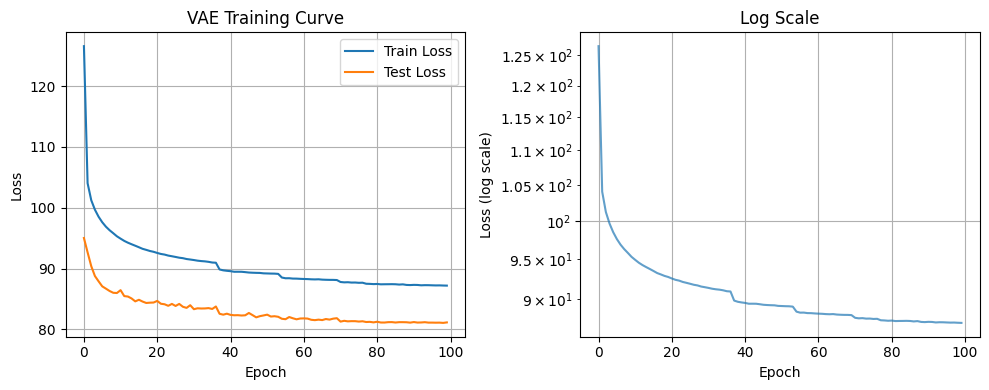

In [118]:
model = CVAE(latent_dim=64, num_classes=10).to(device)

train_losses, test_losses = train_cvae(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    num_epochs=100,
    lr=1e-3,
    device=device,
    log_interval=10,
    save_path='cvae_mnist.pth',
    patience=15,
    use_scheduler=True
)

plot_losses(train_losses, test_losses)

### Sampling


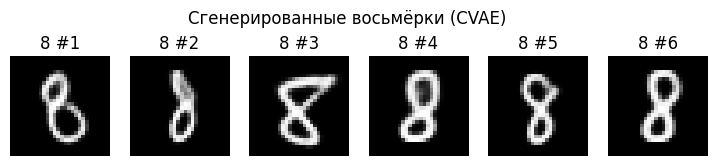

In [119]:
model.load_state_dict(
    torch.load(
        'cvae_mnist.pth', 
        map_location=device
    )['model_state_dict']
)

model.eval()

# 6 восьмёрок
n = 6
labels = torch.full((n,), 8, dtype=torch.long).to(device)  # [8,8,8,8,8,8]
z = torch.randn(n, model.latent_dim).to(device)
with torch.no_grad():
    generated = model.decode(z, labels)

fig, axes = plt.subplots(1, n, figsize=(n*1.5, 2))
for i in range(n):
    axes[i].imshow(generated[i, 0].cpu(), cmap='gray')
    axes[i].set_title(f'8 #{i+1}')
    axes[i].axis('off')
plt.suptitle('Сгенерированные восьмёрки (CVAE)')
plt.show()

Тут мы будем сэмплировать из CVAE. Это прикольнее, чем сэмплировать из простого AE/VAE: тут можно взять один и тот же латентный вектор и попросить CVAE восстановить из него картинки разных классов!
Для MNIST вы можете попросить CVAE восстановить из одного латентного вектора, например, картинки цифры 5 и 7.

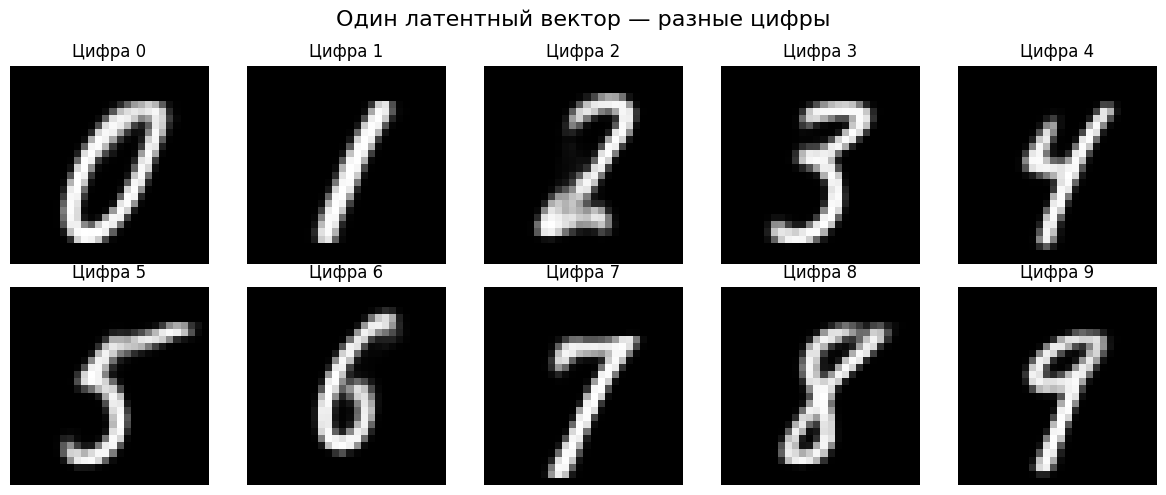

In [120]:
z = torch.randn(1, model.latent_dim).to(device)  # [1, 64]

class_labels = torch.tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]).to(device)  # все 10 цифр

with torch.no_grad():
    generated_imgs = []
    for label in class_labels:
        img = model.decode(z, label.unsqueeze(0))  # decode(z, [label])
        generated_imgs.append(img.squeeze().cpu())

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Один латентный вектор — разные цифры', fontsize=16)

for i, img in enumerate(generated_imgs):
    ax = axes[i // 5, i % 5]
    ax.imshow(img, cmap='gray')
    ax.set_title(f'Цифра {i}', fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()


#<тут нужно научиться сэмплировать из декодера цифры определенного класса>

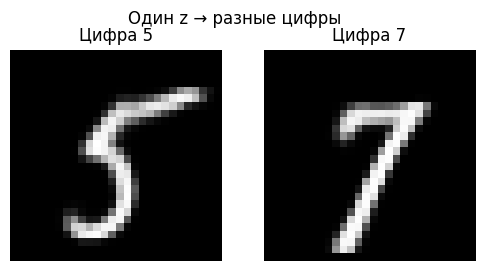

In [121]:
# 5 и 7
labels_to_compare = torch.tensor([5, 7]).to(device)
with torch.no_grad():
    imgs = [model.decode(z, label.unsqueeze(0)).squeeze().cpu() for label in labels_to_compare]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 3))
ax1.imshow(imgs[0], cmap='gray')
ax1.set_title('Цифра 5')
ax1.axis('off')
ax2.imshow(imgs[1], cmap='gray')
ax2.set_title('Цифра 7')
ax2.axis('off')
plt.suptitle('Один z → разные цифры')
plt.show()

Splendid! Вы великолепны!


### Latent Representations

Давайте посмотрим, как выглядит латентное пространство картинок в CVAE и сравним с картинкой для VAE =)

Опять же, нужно покрасить точки в разные цвета в зависимости от класса.

извлечено 10000 латентных векторов, размерность: 64
t-SNE...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 10000 samples in 0.000s...
[t-SNE] Computed neighbors for 10000 samples in 0.269s...
[t-SNE] Computed conditional probabilities for sample 1000 / 10000
[t-SNE] Computed conditional probabilities for sample 2000 / 10000
[t-SNE] Computed conditional probabilities for sample 3000 / 10000
[t-SNE] Computed conditional probabilities for sample 4000 / 10000
[t-SNE] Computed conditional probabilities for sample 5000 / 10000
[t-SNE] Computed conditional probabilities for sample 6000 / 10000
[t-SNE] Computed conditional probabilities for sample 7000 / 10000
[t-SNE] Computed conditional probabilities for sample 8000 / 10000
[t-SNE] Computed conditional probabilities for sample 9000 / 10000
[t-SNE] Computed conditional probabilities for sample 10000 / 10000
[t-SNE] Mean sigma: 0.923691
[t-SNE] KL divergence after 50 iterations with early exaggeration: 94.927818
[t-SNE] KL divergen

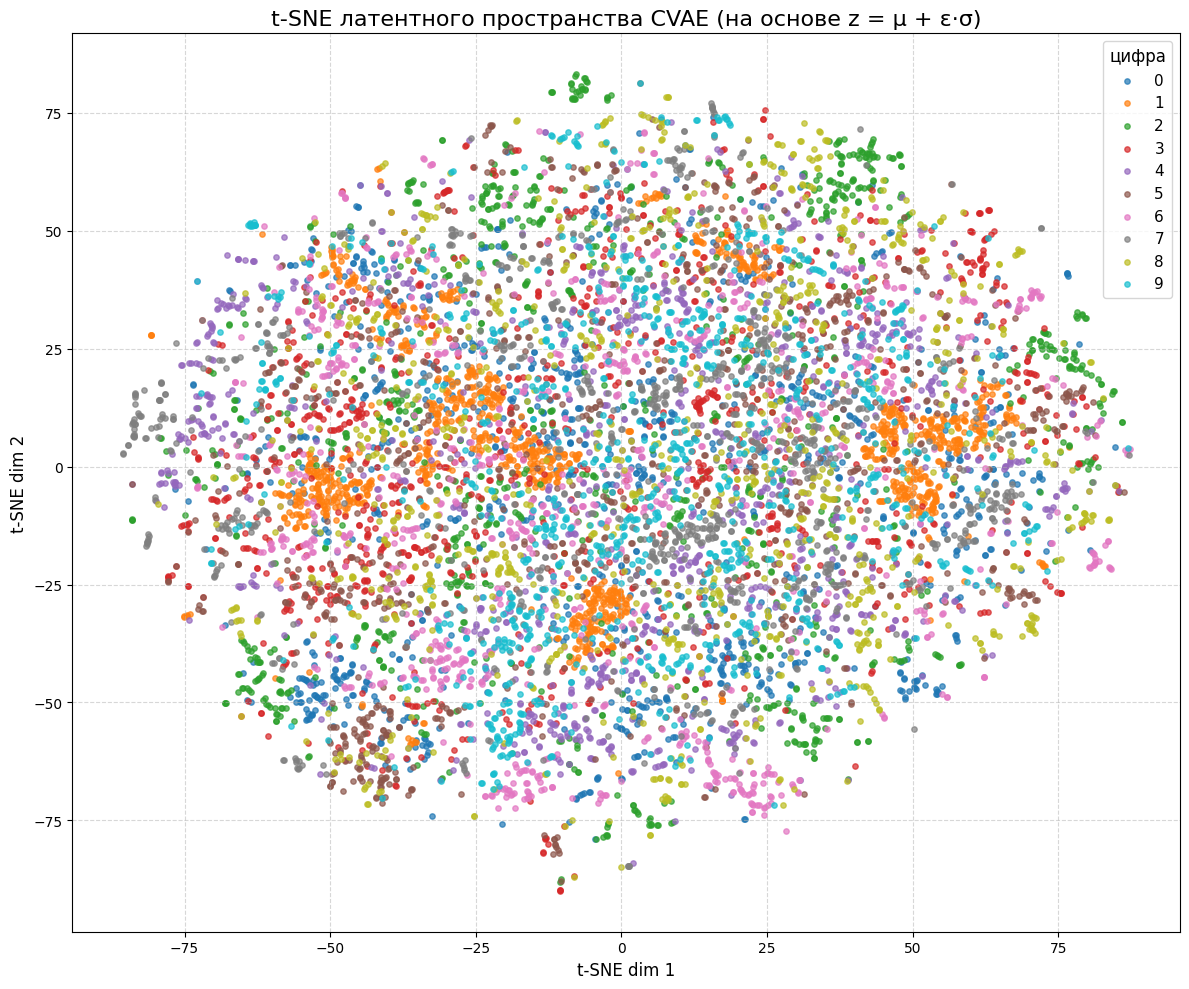

In [124]:
model.eval()

latent_vectors = []
labels = []

with torch.no_grad():
    for batch_idx, (data, target) in enumerate(test_loader):
        data = data.to(device)
        target = target.to(device)  
        
        #(data, labels)
        mu, logvar = model.encode(data, target)
        z = model.gaussian_sampler(mu, logvar)  
        
        latent_vectors.append(z.cpu().numpy())
        labels.append(target.cpu().numpy())

latent_vectors = np.concatenate(latent_vectors, axis=0)  
labels = np.concatenate(labels, axis=0)                 

print(f'извлечено {latent_vectors.shape[0]} латентных векторов, размерность: {latent_vectors.shape[1]}')

print('t-SNE...')
tsne = TSNE(
    n_components=2,
    perplexity=30,        
    #n_iter=1000,
    random_state=42,
    verbose=1             
)
latent_2d = tsne.fit_transform(latent_vectors)

plt.figure(figsize=(12, 10))
colors = plt.cm.tab10(np.linspace(0, 1, 10))  

for i in range(10):
    mask = (labels == i)
    plt.scatter(
        latent_2d[mask, 0], 
        latent_2d[mask, 1], 
        c=[colors[i]], 
        label=str(i), 
        alpha=0.7,
        s=15  
    )

plt.title('t-SNE латентного пространства CVAE (на основе z = μ + ε·σ)', fontsize=16)
plt.xlabel('t-SNE dim 1', fontsize=12)
plt.ylabel('t-SNE dim 2', fontsize=12)
plt.legend(title='цифра', fontsize=11, title_fontsize=12, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

Что вы думаете насчет этой картинки? Отличается от картинки для VAE?

распределение точек в латентном пространстве сильно отличается от распределения простого VAE - сложно выделить какую-либо кластерную структуру, точки различных классов распределены равномернее.

CVAE неплохо справляется с задачей генерации новых картинок определенного класса. 

это связано с наличием подпрастранства бинарных признаков, отвечающих различным классам, которое добавлены при работе с CVAE.

информация о классе явно передаётся в декодер (через y), поэтому z может быть нейтральным по классу - кодируется только "стиль", "форма", "толщина", "наклон".

z — стиль письма может быть универсальным для всех классов,
y — это семантика (что за цифра).

# BONUS 1: Denoising (2 балла)

## Внимание! За бонусы доп. баллы не ставятся, но вы можете сделать их для себя.

У автоэнкодеров, кроме сжатия и генерации изображений, есть другие практические применения. Про одно из них эта бонусная часть задания.

Автоэнкодеры могут быть использованы для избавления от шума на фотографиях (denoising). Для этого их нужно обучить специальным образом: input картинка будет зашумленной, а выдавать автоэнкодер должен будет картинку без шума.
То есть, loss-функция AE останется той же (MSE между реальной картинкой и выданной), а на вход автоэнкодеру будет подаваться зашумленная картинка.

<a href="https://ibb.co/YbRJ1nZ"><img src="https://i.ibb.co/0QD164t/Screen-Shot-2020-06-04-at-4-49-50-PM.png" alt="Screen-Shot-2020-06-04-at-4-49-50-PM" border="0"></a>

Для этого нужно взять ваш любимый датасет (датасет лиц из первой части этого задания или любой другой) и сделать копию этого датасета с шумом.

В питоне шум можно добавить так:

In [126]:
noise_factor = 0.2
#X_noisy = X + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=X.shape)

In [127]:
def add_noise(tensor_batch, noise_factor=0.2, clip=True):
    """
    Добавляет гауссов шум к батчу тензоров [B, C, H, W], значения в [0, 1].
    """
    noise = torch.randn_like(tensor_batch) * noise_factor
    noisy = tensor_batch + noise
    if clip:
        noisy = torch.clamp(noisy, 0.0, 1.0) 
    return noisy

In [128]:
noise_factor = 0.2

# шум в тренировочные и валидационные данные
train_photos_noisy = add_noise(train_photos_tensor, noise_factor=noise_factor)
val_photos_noisy = add_noise(val_photos_tensor, noise_factor=noise_factor)

# новые DataLoader'ы
train_noisy_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(train_photos_noisy, train_photos_tensor), 
    batch_size=32, shuffle=True
)

val_noisy_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(val_photos_noisy, val_photos_tensor),
    batch_size=32, shuffle=False
)

In [129]:
def train_dae_loop(autoencoder, n_epochs=50, noise_factor=0.2, **kwargs):
    plt.ion()
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    train_line, = ax.plot([], [], 'b-', label='Train')
    val_line, = ax.plot([], [], 'r--', label='Val')
    ax.legend(); ax.grid(); plt.tight_layout()

    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    epochs_no_improve = 0
    patience = kwargs.get('patience', 5)
    min_delta = kwargs.get('min_delta', 1e-4)

    for epoch in range(n_epochs):

        autoencoder.train()
        total_train_loss = 0.0
        for noisy_batch, clean_batch in train_noisy_loader:
            noisy_batch = noisy_batch.to(device)
            clean_batch = clean_batch.to(device)

            optimizer.zero_grad()
            recon, _ = autoencoder(noisy_batch)  # зашумлённый
            loss = criterion(recon, clean_batch)  # чистый
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item() * noisy_batch.size(0)

        avg_train_loss = total_train_loss / len(train_noisy_loader.dataset)
        train_losses.append(avg_train_loss)

        autoencoder.eval()
        total_val_loss = 0.0
        with torch.no_grad():
            for noisy_batch, clean_batch in val_noisy_loader:
                noisy_batch = noisy_batch.to(device)
                clean_batch = clean_batch.to(device)
                recon, _ = autoencoder(noisy_batch)
                loss = criterion(recon, clean_batch)
                total_val_loss += loss.item() * noisy_batch.size(0)

        avg_val_loss = total_val_loss / len(val_noisy_loader.dataset)
        val_losses.append(avg_val_loss)

        # Early stopping & saving
        if avg_val_loss < best_val_loss - min_delta:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            torch.save(autoencoder.state_dict(), 'best_dae.pth')
            print(f'Epoch {epoch+1}: сохраняем улучшение (val loss: {avg_val_loss:.6f})')
        else:
            epochs_no_improve += 1

        if epoch % 3 == 0 or epoch == n_epochs - 1:
            print(f'Epoch {epoch+1}/{n_epochs} | Train: {avg_train_loss:.6f} | Val: {avg_val_loss:.6f}')

        xs = list(range(1, len(train_losses)+1))
        train_line.set_data(xs, train_losses)
        val_line.set_data(xs, val_losses)
        ax.relim(); ax.autoscale_view()
        fig.canvas.draw(); fig.canvas.flush_events()

        if epochs_no_improve >= patience:
            print(f'остановка на эпохе {epoch+1}')
            break

    plt.ioff()
    plt.show()

In [130]:
def eval_denoising(autoencoder, n_samples=5, noise_factor=0.2, seed=42):
    autoencoder.eval()
    torch.manual_seed(seed)
    
    # случайные чистые изображения
    indices = torch.randperm(len(val_photos_tensor))[:n_samples]
    clean_samples = val_photos_tensor[indices].to(device)
    
    # шум "в реальном времени"
    noisy_samples = add_noise(clean_samples, noise_factor=noise_factor)

    with torch.no_grad():
        denoised, _ = autoencoder(noisy_samples)
        denoised = denoised.clamp(0, 1)

    plt.figure(figsize=(9, 2 * n_samples))
    for i in range(n_samples):
        # Оригинал
        plt.subplot(n_samples, 3, 3*i+1)
        plt.imshow(clean_samples[i].cpu().permute(1, 2, 0))
        plt.title("Original", fontsize=9); plt.axis('off')

        # Зашумлённое
        plt.subplot(n_samples, 3, 3*i+2)
        plt.imshow(noisy_samples[i].cpu().permute(1, 2, 0).clamp(0, 1))
        plt.title(f"Noisy (σ={noise_factor})", fontsize=9); plt.axis('off')

        # Восстановленное
        plt.subplot(n_samples, 3, 3*i+3)
        plt.imshow(denoised[i].cpu().permute(1, 2, 0))
        plt.title("Denoised", fontsize=9); plt.axis('off')

    plt.tight_layout()
    plt.show()

Epoch 1: сохраняем улучшение (val loss: 0.006115)
Epoch 1/50 | Train: 0.010522 | Val: 0.006115
Epoch 2: сохраняем улучшение (val loss: 0.004139)
Epoch 3: сохраняем улучшение (val loss: 0.003793)
Epoch 4: сохраняем улучшение (val loss: 0.003469)
Epoch 4/50 | Train: 0.004231 | Val: 0.003469
Epoch 5: сохраняем улучшение (val loss: 0.003084)
Epoch 7: сохраняем улучшение (val loss: 0.002770)
Epoch 7/50 | Train: 0.003544 | Val: 0.002770
Epoch 8: сохраняем улучшение (val loss: 0.002662)
Epoch 10/50 | Train: 0.003253 | Val: 0.002905
Epoch 13: сохраняем улучшение (val loss: 0.002352)
Epoch 13/50 | Train: 0.003042 | Val: 0.002352
Epoch 16/50 | Train: 0.002900 | Val: 0.002319
Epoch 18: сохраняем улучшение (val loss: 0.002239)
Epoch 19: сохраняем улучшение (val loss: 0.002121)
Epoch 19/50 | Train: 0.002721 | Val: 0.002121
Epoch 22/50 | Train: 0.002641 | Val: 0.002278
остановка на эпохе 24


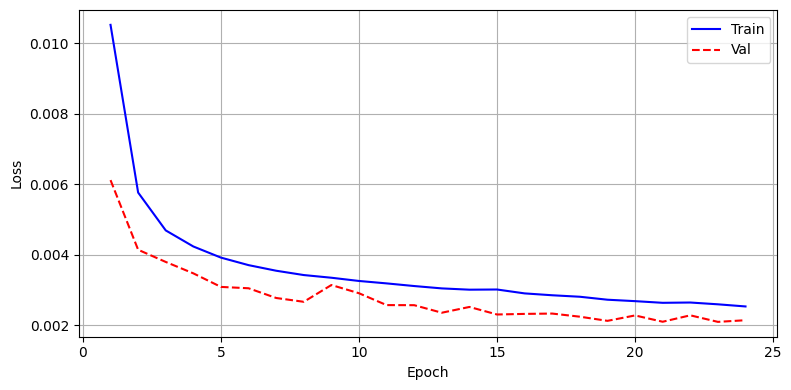

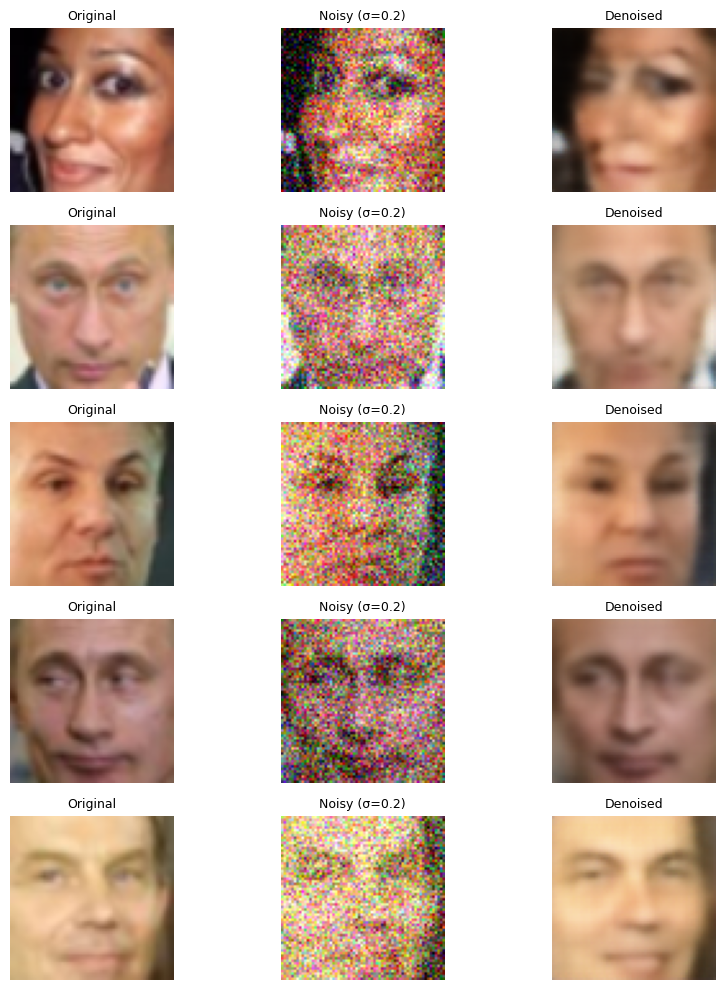

In [131]:
dae_model = Autoencoder(latent_dim=256, in_channels=3, dropout_p=0.2).to(device)
optimizer = torch.optim.AdamW(dae_model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

train_dae_loop(dae_model, n_epochs=50, noise_factor=noise_factor)

dae_model.load_state_dict(torch.load('best_dae.pth'))
eval_denoising(dae_model, noise_factor=0.2)

In [ ]:
<тут ваш код обучения автоэнкодера на зашумленных картинках. Не забудьте разбить на train/test!>

In [ ]:
<тут проверка, как AE убирает шум с тестовых картинок. Надеюсь, все получилось =)>

# BONUS 2: Image Retrieval (2 балла)

## Внимание! За бонусы доп. баллы не ставятся, но вы можете сделать их для себя.

Давайте представим, что весь наш тренировочный датасет -- это большая база данных людей. И вот мы получили картинку лица какого-то человека с уличной камеры наблюдения (у нас это картинка из тестового датасета) и хотим понять, что это за человек. Что нам делать? Правильно -- берем наш VAE, кодируем картинку в латентное представление и ищем среди латентных представлений лиц нашей базы самые ближайшие!

План:

1. Получаем латентные представления всех лиц тренировочного датасета
2. Обучаем на них LSHForest `(sklearn.neighbors.LSHForest)`, например, с `n_estimators=50`
3. Берем картинку из тестового датасета, с помощью VAE получаем ее латентный вектор
4. Ищем с помощью обученного LSHForest ближайшие из латентных представлений тренировочной базы
5. Находим лица тренировочного датасета, которым соответствуют ближайшие латентные представления, визуализируем!

Немного кода вам в помощь: (feel free to delete everything and write your own)

In [ ]:
codes = <поучите латентные представления картинок из трейна>

In [ ]:
# обучаем LSHForest
from sklearn.neighbors import LSHForest
lshf = LSHForest(n_estimators=50).fit(codes)

In [ ]:
def get_similar(image, n_neighbors=5):
  # функция, которая берет тестовый image и с помощью метода kneighbours у LSHForest ищет ближайшие векторы
  # прогоняет векторы через декодер и получает картинки ближайших людей

  code = <получение латентного представления image>

  (distances,),(idx,) = lshf.kneighbors(code, n_neighbors=n_neighbors)

  return distances, X_train[idx]

In [ ]:
def show_similar(image):

  # функция, которая принимает тестовый image, ищет ближайшие к нему и визуализирует результат

    distances,neighbors = get_similar(image,n_neighbors=11)

    plt.figure(figsize=[8,6])
    plt.subplot(3,4,1)
    plt.imshow(image.cpu().numpy().transpose([1,2,0]))
    plt.title("Original image")

    for i in range(11):
        plt.subplot(3,4,i+2)
        plt.imshow(neighbors[i].cpu().numpy().transpose([1,2,0]))
        plt.title("Dist=%.3f"%distances[i])
    plt.show()

In [ ]:
<тут выведите самые похожие лица к какому-нибудь лицу из тестовой части датасета>